# Question 1 — rolling-origin forecasting for the next eight years

This notebook compares four forecasting methods for **London overall**, **Inner and Outer London**, and **all 32 boroughs** at monthly, quarterly and annual frequencies.

Formal model and hyperparameter selection uses four expanding rolling origins: **Years 1–3 predict Year 4, Years 1–4 predict Year 5, Years 1–5 predict Year 6, and Years 1–6 predict Year 7**. Candidates are ranked by mean precision-weighted total-variation error across those four validation years. Year 8 is reserved for final testing after the selected specification is refitted on Years 1–7.


## 1. Data and forecasting rules

The three outcomes are **Inactive**, **Fairly Active** and **Active**. They are forecast together and projected back onto a valid composition, so every point is between 0% and 100% and the three values always add to 100%.

The base model uses only information available at the forecast origin: previous activity composition, the same period one year earlier, a short recent mean, calendar season and a gradual trend. A separate Year 7 experiment studies exactly three interpretable external variables: **population aged 65+**, **adult-population growth**, and **median weekly earnings**.

The variables are tested one at a time with a one-year lag. They are not combined and are not promoted into the official model. Year 8 testing and future eight-year forecasts therefore remain based on activity history alone.


In [1]:
# Load the three prepared panels and the modelling libraries.
from pathlib import Path
import os
import warnings

os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
# Load the libraries required for this section.
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
# Load the libraries required for this section.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 2026
CV_ORIGINS = [3, 4, 5, 6]
TEST_YEAR = 8
MODEL_TOLERANCE = .02
TARGETS = ['inactive_rate', 'fairly_active_rate', 'active_rate']
# Select the variables needed for this part of the analysis.
TARGET_LABELS = {'inactive_rate': 'Inactive', 'fairly_active_rate': 'Fairly Active', 'active_rate': 'Active'}
MODELS = ['Naive baseline', 'Ridge Regression', 'Random Forest', 'Gradient Boosting']
MODEL_PARAMETER_GRID = {
    'Naive baseline': [{}],
    'Ridge Regression': [
        {'alpha': alpha} for alpha in (.1, 1.0, 10.0, 100.0, 1000.0)
    ],
    'Random Forest': [
        {'n_estimators': 300, 'max_depth': 6, 'min_leaf_fraction': .02, 'max_features': .5},
        {'n_estimators': 300, 'max_depth': 10, 'min_leaf_fraction': .01, 'max_features': .8},
        {'n_estimators': 300, 'max_depth': None, 'min_leaf_fraction': .005, 'max_features': 1.0},
        {'n_estimators': 300, 'max_depth': None, 'min_leaf_fraction': .02, 'max_features': .8},
        {'n_estimators': 300, 'max_depth': 10, 'min_leaf_fraction': .01, 'max_features': .5},
    ],
    'Gradient Boosting': [
        {'n_estimators': 500, 'learning_rate': .01, 'max_depth': 2, 'min_leaf_fraction': .01},
        {'n_estimators': 200, 'learning_rate': .025, 'max_depth': 2, 'min_leaf_fraction': .01},
        {'n_estimators': 100, 'learning_rate': .05, 'max_depth': 2, 'min_leaf_fraction': .01},
        {'n_estimators': 50, 'learning_rate': .10, 'max_depth': 2, 'min_leaf_fraction': .01},
        {'n_estimators': 100, 'learning_rate': .05, 'max_depth': 1, 'min_leaf_fraction': .01},
        {'n_estimators': 100, 'learning_rate': .05, 'max_depth': 3, 'min_leaf_fraction': .01},
    ],
}
MODEL_COLORS = {
    'Naive baseline': '#9E9E9E', 'Ridge Regression': '#4C72B0',
    'Random Forest': '#55A868', 'Gradient Boosting': '#C44E52',
}
LEVELS = ['London', 'Inner/Outer', 'Borough']
# Calculate and store FREQUENCIES for the following analysis step.
FREQUENCIES = ['Monthly', 'Quarterly', 'Annual']

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / 'question1_outputs').exists() else cwd.parent
DATA_DIR = PROJECT_ROOT / 'question1_outputs' / 'prepared_data'
BOUNDARY_PATH = PROJECT_ROOT / 'extradata' / 'london_borough_boundaries.geojson'
FREQUENCY_CONFIG = {
    'Monthly': {
        'path': DATA_DIR / 'q1_monthly.csv', 'time': 'month_index',
        'date': 'period_start', 'periods_per_year': 12, 'seasonal_lag': 12,
        'recent_window': 3, 'backtest_start': 73, 'future_periods': 96,
    },
    'Quarterly': {
        'path': DATA_DIR / 'q1_quarterly.csv', 'time': 'quarter_index',
        'date': 'quarter_start', 'periods_per_year': 4, 'seasonal_lag': 4,
        'recent_window': 2, 'backtest_start': 25, 'future_periods': 32,
    },
    'Annual': {
        'path': DATA_DIR / 'q1_annual.csv', 'time': 'year',
        'date': None, 'periods_per_year': 1, 'seasonal_lag': 1,
        'recent_window': 1, 'backtest_start': 5, 'future_periods': 8,
    },
}

# Prepare the data used in the next calculation or visualisation.
frequency_frames = {}
for frequency, config in FREQUENCY_CONFIG.items():
    frame = pd.read_csv(config['path'])
    if config['date']:
        frame[config['date']] = pd.to_datetime(frame[config['date']])
    frequency_frames[frequency] = frame

# Calculate and store borough boundaries for the following analysis step.
borough_boundaries = gpd.read_file(BOUNDARY_PATH)[['gss_code', 'name', 'geometry']]

# Derive adult-population growth once per geography-year, then attach it to each frequency.
for frequency, frame in frequency_frames.items():
    population_year = frame[[
        'geography_code', 'year', 'adult_population'
    ]].drop_duplicates(['geography_code', 'year']).sort_values(['geography_code', 'year'])
    population_year['adult_population_growth'] = population_year.groupby(
        'geography_code'
    )['adult_population'].pct_change()
    frequency_frames[frequency] = frame.merge(
        population_year[['geography_code', 'year', 'adult_population_growth']],
        on=['geography_code', 'year'], validate='many_to_one'
    )



### Independent validation

The compact audit below checks the number of geographies and periods, duplicate geography–time keys, missing outcomes and the largest deviation from a 100% composition. These checks are repeated here so forecasting does not depend silently on Notebook 01 having run correctly.


In [2]:
# Build the nine modelling panels and summarise their validity.
LEVEL_FILTERS = {'London': 'London', 'Inner/Outer': 'InnerOuter', 'Borough': 'Borough'}
panels, audit_rows = {}, []

for frequency, frame in frequency_frames.items():
    time_column = FREQUENCY_CONFIG[frequency]['time']
    for level, source_label in LEVEL_FILTERS.items():
        panel = frame.loc[frame['geography_level'].eq(source_label)].copy()
        panel = panel.sort_values(['geography_code', time_column]).reset_index(drop=True)
        panels[(level, frequency)] = panel
        complete_targets = panel[TARGETS].notna().all(axis=1)
        composition_error = (panel.loc[complete_targets, TARGETS].sum(axis=1) - 1).abs().max()
        audit_rows.append({
            'Geography': level, 'Frequency': frequency,
            'Areas': panel['geography_code'].nunique(),
            'Periods': panel[time_column].nunique(),
            'Duplicate keys': panel.duplicated(['geography_code', time_column]).sum(),
            'Rows with missing outcomes': int((~complete_targets).sum()),
            'Maximum sum error': composition_error,
            'Median effective n': panel['effective_n'].median(),
        })

# Define the time split or forecast horizon used for evaluation.
validation_summary = pd.DataFrame(audit_rows)
assert validation_summary['Duplicate keys'].eq(0).all()
assert validation_summary['Maximum sum error'].lt(1e-8).all()
display(validation_summary.round({'Maximum sum error': 8, 'Median effective n': 0}))


,Geography,Frequency,Areas,Periods,Duplicate keys,Rows with missing outcomes,Maximum sum error,Median effective n
0,London,Monthly,1,96,0,0,0.0,746.0
1,Inner/Outer,Monthly,2,96,0,0,0.0,366.0
2,Borough,Monthly,32,96,0,1,0.0,25.0
3,London,Quarterly,1,32,0,0,0.0,2134.0
4,Inner/Outer,Quarterly,2,32,0,0,0.0,1071.0
5,Borough,Quarterly,32,32,0,0,0.0,71.0
6,London,Annual,1,8,0,0,0.0,9163.0
7,Inner/Outer,Annual,2,8,0,0,0.0,4570.0
8,Borough,Annual,32,8,0,0,0.0,295.0


## 2. One shared rolling-origin framework

The same functions are used for all nine tasks. Monthly and quarterly models include a one-year seasonal lag; annual models use the previous year. Ridge can extend a gradual trend, whereas Random Forest and Gradient Boosting are flexible but cannot extrapolate beyond patterns seen in training. The Naive baseline repeats the same period from the previous year, or the previous annual value.

Each parameter candidate is evaluated at four one-year-ahead origins. The arithmetic mean of the four fold-level weighted TV errors gives every survey year equal influence; fold standard deviation and the worst fold describe temporal sensitivity. A 2% simple-model tolerance is used: a simpler family is preferred only when its mean CV error is within 2% of the minimum. Selection under 0%, 1%, 2% and 5% tolerances is also reported as a threshold-sensitivity check.

The parameter ranges are pre-specified rather than chosen from Year 8. Ridge alpha spans 0.1–1000 on a logarithmic scale, covering weak through strong shrinkage after standardisation. Random Forest evaluates five profiles ranging from shallow, large-leaf regularisation to unrestricted depth and smaller leaves; leaf sizes are 0.5%, 1% or 2% of the fold-specific training sample so the strength has the same interpretation at all geographic levels. Three hundred trees are held fixed to reduce Monte Carlo noise while keeping the rolling exercise feasible. Gradient Boosting tests learning rates 0.01, 0.025, 0.05 and 0.10 with approximately inverse tree counts, so the overall boosting budget is comparable, and tests depths 1–3 around the depth-2 reference.

Missing feature values that occur at early origins are median-imputed inside each training pipeline. A missing activity-history point is filled first from the same period one year earlier, then from prior training history if needed; every fill is therefore origin-safe. Rows without an observed three-part outcome or a positive effective sample size cannot be scored and are excluded identically for every candidate. No validation or test information enters preprocessing. After the model family and its parameters are frozen, it is refitted on Years 1–7 and evaluated once on Year 8. Total variation and precision weighting are applied consistently throughout.


In [3]:
# Create lagged features and recursive forecasting functions.
EXTERNAL_EXPERIMENTS = {
    'Base history only': [],
    'Age: 65+ share': ['population_age_65_plus_rate'],
    'Population: growth': ['adult_population_growth'],
    'Income: weekly earnings': ['median_weekly_earnings_gbp'],
}


# Define project composition once so the same rule is reused consistently.
def project_composition(values):
    """Clip predictions to positive values and rescale every row to sum to one."""
    values = np.clip(np.asarray(values, dtype=float), 1e-6, None)
    return values / values.sum(axis=1, keepdims=True)


def make_supervised(panel, config, external_features=None):
    """Create strictly lagged predictors and remove genuine warm-up rows."""
    external_features = external_features or []
    time_column = config['time']
    result = panel.sort_values(['geography_code', time_column]).copy()
    grouped = result.groupby('geography_code', sort=False)
    feature_columns = []
    for target in TARGETS:
        lag1 = f'{target}_lag1'
        result[lag1] = grouped[target].shift(1)
        feature_columns.append(lag1)
        if config['seasonal_lag'] > 1:
            seasonal = f'{target}_seasonal_lag'
            result[seasonal] = grouped[target].shift(config['seasonal_lag'])
            feature_columns.append(seasonal)
        # Calculate and store recent for the following analysis step.
        recent = f'{target}_recent_mean'
        result[recent] = grouped[target].transform(
            lambda series: series.shift(1).rolling(config['recent_window']).mean()
        )
        feature_columns.append(recent)

    # Context always comes from the corresponding period one year earlier.
    context_lag = config['periods_per_year']
    for feature in external_features:
        lagged = f'{feature}_context_lag'
        result[lagged] = grouped[feature].shift(context_lag)
        feature_columns.append(lagged)

    result['trend_years'] = result[time_column] / config['periods_per_year']
    feature_columns.append('trend_years')
    # Apply the appropriate rule for the available data in this case.
    if config['periods_per_year'] > 1:
        phase = 2 * np.pi * (result[time_column] - 1) / config['periods_per_year']
        result['season_sin'], result['season_cos'] = np.sin(phase), np.cos(phase)
        feature_columns += ['season_sin', 'season_cos']
    result = result.dropna(subset=feature_columns + TARGETS).reset_index(drop=True)
    return result, feature_columns


# Define build model once so the same rule is reused consistently.
def build_model(model_name, numeric_features, training_rows, parameters=None):
    """Return a sample-size-aware pipeline for one fitted parameter candidate."""
    parameters = parameters or {}
    numeric_transformer = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ])
    transformer = ColumnTransformer([
        ('numeric', numeric_transformer, numeric_features),
        ('geography', OneHotEncoder(handle_unknown='ignore', drop='first'), ['geography_code']),
    ])
    leaf_fraction = parameters.get('min_leaf_fraction', .01)
    leaf = max(1, int(np.ceil(training_rows * leaf_fraction)))
    if model_name == 'Ridge Regression':
        estimator = Ridge(alpha=parameters.get('alpha', 10.0))
    elif model_name == 'Random Forest':
        estimator = RandomForestRegressor(
            n_estimators=parameters.get('n_estimators', 300),
            max_depth=parameters.get('max_depth'),
            min_samples_leaf=leaf,
            max_features=parameters.get('max_features', .8),
            random_state=RANDOM_STATE, n_jobs=-1,
        )
    else:
        estimator = MultiOutputRegressor(GradientBoostingRegressor(
            n_estimators=parameters.get('n_estimators', 100),
            learning_rate=parameters.get('learning_rate', .05),
            max_depth=parameters.get('max_depth', 2),
            min_samples_leaf=leaf, random_state=RANDOM_STATE,
        ))
    # Return the completed result to the calling analysis step.
    return Pipeline([('prepare', transformer), ('model', estimator)])


# Define weighted tv once so the same rule is reused consistently.
def weighted_tv(actual, predicted, weights):
    """Calculate precision-weighted total variation for three-part outcomes."""
    row_error = .5 * np.abs(np.asarray(actual) - np.asarray(predicted)).sum(axis=1)
    return np.average(row_error, weights=np.asarray(weights)), row_error


def forecast_metrics(matched):
    """Return precision-weighted TV, MAE, RMSE and outcome-specific MAE."""
    predicted_columns = [f'predicted_{target}' for target in TARGETS]
    actual = matched[TARGETS].to_numpy()
    predicted = matched[predicted_columns].to_numpy()
    weights = matched['effective_n'].to_numpy()
    errors = predicted - actual
    absolute_errors = np.abs(errors)
    tv_error, _ = weighted_tv(actual, predicted, weights)
    target_mae = np.average(absolute_errors, axis=0, weights=weights)
    return {
        'weighted_tv': tv_error,
        'weighted_mae': target_mae.mean(),
        'weighted_rmse': np.sqrt(
            np.average(np.square(errors).mean(axis=1), weights=weights)
        ),
        **{f'{target}_mae': target_mae[i] for i, target in enumerate(TARGETS)},
    }


def rolling_forecast_metrics(matched):
    """Average fold-level metrics so each validation year has equal influence."""
    fold_metrics = pd.DataFrame([
        forecast_metrics(fold) for _, fold in matched.groupby('cv_fold', sort=True)
    ])
    result = fold_metrics.mean().to_dict()
    result['folds'] = matched['cv_fold'].nunique()
    result['scored_rows'] = len(matched)
    return result


def future_feature_row(code_value, history, context, next_time, config,
                       numeric_features, external_features):
    """Create one future row using predicted activity and last-known context."""
    row = {'geography_code': code_value, 'trend_years': next_time / config['periods_per_year']}
    for position, target in enumerate(TARGETS):
        series = history[:, position]
        row[f'{target}_lag1'] = series[-1]
        if config['seasonal_lag'] > 1:
            row[f'{target}_seasonal_lag'] = series[-config['seasonal_lag']]
        row[f'{target}_recent_mean'] = series[-config['recent_window']:].mean()
    # Repeat the same calculation across the required groups or settings.
    for feature in external_features:
        row[f'{feature}_context_lag'] = context[feature]
    if config['periods_per_year'] > 1:
        phase = 2 * np.pi * (next_time - 1) / config['periods_per_year']
        row['season_sin'], row['season_cos'] = np.sin(phase), np.cos(phase)
    return pd.DataFrame([row])[numeric_features + ['geography_code']]


# Define recursive forecast once so the same rule is reused consistently.
def recursive_forecast(panel, config, model_name, external_features=None, horizon=None,
                       excluded_features=None, model_parameters=None):
    """Fit one recursive forecast, optionally omitting named predictors for ablation."""
    external_features = external_features or []
    excluded_features = set(excluded_features or [])
    supervised, numeric_features = make_supervised(panel, config, external_features)
    numeric_features = [feature for feature in numeric_features if feature not in excluded_features]
    horizon = horizon or config['future_periods']
    model = None
    if model_name != 'Naive baseline':
        weights = np.clip(
            supervised['effective_n'], supervised['effective_n'].quantile(.05),
            supervised['effective_n'].quantile(.95),
        )
        weights = weights / weights.mean()
        model = build_model(
            model_name, numeric_features, len(supervised), model_parameters
        )
        model.fit(
            supervised[numeric_features + ['geography_code']], supervised[TARGETS],
            model__sample_weight=weights,
        )

    # Select the variables needed for this part of the analysis.
    time_column = config['time']
    last_time = int(panel[time_column].max())
    rows = []
    for code_value, group in panel.groupby('geography_code', sort=False):
        group = group.sort_values(time_column)
        history_frame = group[TARGETS].copy()
        history_frame = history_frame.fillna(
            history_frame.shift(config['periods_per_year'])
        ).ffill().fillna(supervised[TARGETS].mean())
        history = project_composition(history_frame.to_numpy())
        assert np.isfinite(history).all()
        context = {feature: group[feature].dropna().iloc[-1] for feature in external_features}
        geography_name = group['geography_name'].iloc[0]
        for step in range(1, horizon + 1):
            next_time = last_time + step
            if model_name == 'Naive baseline':
                lag = config['seasonal_lag'] if config['seasonal_lag'] > 1 else 1
                prediction = history[-lag].reshape(1, -1)
            else:
                features = future_feature_row(
                    code_value, history, context, next_time, config,
                    numeric_features, external_features,
                )
                prediction = model.predict(features)
            # Calculate and store prediction for the following analysis step.
            prediction = project_composition(prediction)[0]
            history = np.vstack([history, prediction])
            rows.append({
                'geography_code': code_value, 'geography_name': geography_name,
                'future_step': step, time_column: next_time,
                **{f'predicted_{target}': prediction[i] for i, target in enumerate(TARGETS)},
            })
    # Return the completed result to the calling analysis step.
    return pd.DataFrame(rows)


# Define score forecast once so the same rule is reused consistently.
def score_forecast(predicted, actual, config):
    """Score observed, positive-weight rows without changing the TV definition."""
    time_column = config['time']
    scorable = (
        actual[TARGETS].notna().all(axis=1)
        & actual['effective_n'].notna()
        & np.isfinite(actual['effective_n'])
        & actual['effective_n'].gt(0)
    )
    matched = predicted.merge(
        actual.loc[scorable, ['geography_code', time_column, 'effective_n', *TARGETS]],
        on=['geography_code', time_column], validate='one_to_one',
    )
    values = matched[[f'predicted_{target}' for target in TARGETS]].to_numpy()
    assert len(matched) and np.isfinite(values).all()
    # Calculate and store  , matched['row tv'] for the following analysis step.
    _, matched['row_tv'] = weighted_tv(matched[TARGETS], values, matched['effective_n'])
    period_scores = matched.groupby(time_column).apply(
        lambda frame: np.average(frame['row_tv'], weights=frame['effective_n']),
        include_groups=False,
    )
    return matched, period_scores


### Rolling validation, three external variables and untouched test

For each task, every base-model parameter candidate forecasts Years 4–7 from four expanding origins. Mean weighted TV across the four years selects the parameter set and model family. Age, population and income are then evaluated separately on Year 7 using the selected family and parameter set.

The external-variable comparison is diagnostic only and cannot change the official specification. The selected base family is refitted without external variables on Years 1–7 and tested once on Year 8. Future eight-year forecasts use the same history-only specification.


,Geography,Frequency,model,parameters,Mean CV TV (pp),Fold SD (pp),Worst fold TV (pp)
0,London,Monthly,Naive baseline,{},3.595,1.070,4.507
3,London,Monthly,Ridge Regression,{'alpha': 10.0},2.728,1.200,4.405
6,London,Monthly,Random Forest,"{'n_estimators': 300, 'max_depth': 6, 'min_lea...",2.894,0.953,3.762
16,London,Monthly,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",2.826,1.229,4.440
17,London,Quarterly,Naive baseline,{},2.388,1.222,3.862
20,London,Quarterly,Ridge Regression,{'alpha': 10.0},2.247,0.757,3.238
23,London,Quarterly,Random Forest,"{'n_estimators': 300, 'max_depth': 6, 'min_lea...",2.455,0.589,3.148
33,London,Quarterly,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",2.455,0.811,3.396
34,London,Annual,Naive baseline,{},1.061,1.044,2.245
39,London,Annual,Ridge Regression,{'alpha': 1000.0},1.685,0.273,1.876


,Model,Parameter candidate,Mean loss vs family best (%),Worst loss vs family best (%),Tasks selected
0,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",3.05,9.05,2
4,Gradient Boosting,"{'n_estimators': 50, 'learning_rate': 0.1, 'ma...",3.19,9.31,2
2,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",3.44,13.28,3
5,Gradient Boosting,"{'n_estimators': 500, 'learning_rate': 0.01, '...",3.59,12.84,1
3,Gradient Boosting,"{'n_estimators': 200, 'learning_rate': 0.025, ...",3.59,11.24,1
1,Gradient Boosting,"{'n_estimators': 100, 'learning_rate': 0.05, '...",4.15,13.26,0
6,Naive baseline,{},0.00,0.00,9
9,Random Forest,"{'n_estimators': 300, 'max_depth': 6, 'min_lea...",0.30,0.95,5
7,Random Forest,"{'n_estimators': 300, 'max_depth': 10, 'min_le...",0.41,0.95,2
8,Random Forest,"{'n_estimators': 300, 'max_depth': 10, 'min_le...",1.30,5.67,1


Simple-model tolerance (%)                0.0               1.0  \
Geography   Frequency                                             
Borough     Annual           Ridge Regression  Ridge Regression   
            Monthly          Ridge Regression  Ridge Regression   
            Quarterly       Gradient Boosting     Random Forest   
Inner/Outer Annual             Naive baseline    Naive baseline   
            Monthly             Random Forest  Ridge Regression   
            Quarterly           Random Forest     Random Forest   
London      Annual             Naive baseline    Naive baseline   
            Monthly          Ridge Regression  Ridge Regression   
            Quarterly        Ridge Regression  Ridge Regression   

Simple-model tolerance (%)               2.0               5.0  
Geography   Frequency                                           
Borough     Annual          Ridge Regression  Ridge Regression  
            Monthly         Ridge Regression  Ridge Regression  
            Quarterly          Random Forest  Ridge Regression  
Inner/Outer Annual            Naive baseline    Naive baseline  
            Monthly         Ridge Regression  Ridge Regression  
            Quarterly          Random Forest    Naive baseline  
London      Annual            Naive baseline    Naive baseline  
            Monthly         Ridge Regression  Ridge Regression  
            Quarterly       Ridge Regression  Ridge Regression

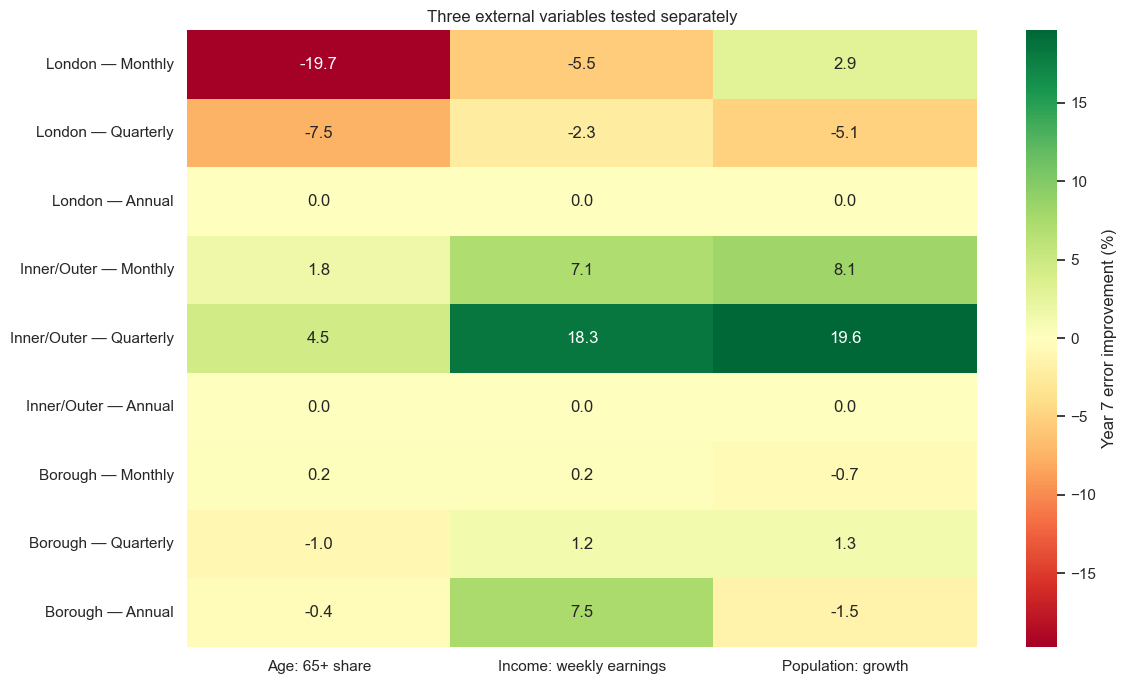

,External variable,Mean improvement (%),Median improvement (%),Tasks improved,Tasks improved by at least 2%
1,Income: weekly earnings,2.9,0.2,5,3
2,Population: growth,2.7,0.0,4,3
0,Age: 65+ share,-2.5,0.0,3,1


In [4]:
# Run four rolling-origin validation folds, then refit the frozen winner for Year 8.
validation_parts, model_rows, external_rows = [], [], []
test_parts, test_rows, future_parts, calibration_parts = [], [], [], []
all_test_parts, rolling_metric_rows, all_test_metric_rows = [], [], []
selection_rows, task_choices = [], {}
parameter_fold_rows, parameter_rows, tolerance_rows = [], [], []

for level in LEVELS:
    for frequency in FREQUENCIES:
        panel, config = panels[(level, frequency)], FREQUENCY_CONFIG[frequency]
        periods = config['periods_per_year']
        train_6 = panel.loc[panel['year'].le(6)].copy()
        validation_actual = panel.loc[panel['year'].eq(7)].copy()
        train_7 = panel.loc[panel['year'].le(7)].copy()
        test_actual = panel.loc[panel['year'].eq(TEST_YEAR)].copy()

        # Stage 1: tune every candidate on the same four rolling origins.
        family_scores = []
        family_predictions = {}
        best_parameters_by_family = {}
        for model_name in MODELS:
            candidate_results = []
            for candidate_id, parameters in enumerate(
                MODEL_PARAMETER_GRID[model_name], start=1
            ):
                fold_errors, fold_predictions = [], []
                for fold_number, origin_year in enumerate(CV_ORIGINS, start=1):
                    fold_train = panel.loc[panel['year'].le(origin_year)].copy()
                    fold_actual = panel.loc[
                        panel['year'].eq(origin_year + 1)
                    ].copy()
                    predicted = recursive_forecast(
                        fold_train, config, model_name, [], periods,
                        model_parameters=parameters,
                    )
                    matched, _ = score_forecast(predicted, fold_actual, config)
                    fold_error = np.average(
                        matched['row_tv'], weights=matched['effective_n']
                    )
                    fold_errors.append(fold_error)
                    matched['cv_fold'] = fold_number
                    matched['training_end_year'] = origin_year
                    matched['validation_year'] = origin_year + 1
                    fold_predictions.append(matched)
                    parameter_fold_rows.append({
                        'Geography': level, 'Frequency': frequency,
                        'model': model_name, 'candidate_id': candidate_id,
                        'parameters': repr(parameters), 'fold': fold_number,
                        'training_years': f'1-{origin_year}',
                        'validation_year': origin_year + 1,
                        'weighted_tv': fold_error,
                    })
                fold_errors = np.asarray(fold_errors)
                candidate_results.append({
                    'candidate_id': candidate_id, 'parameters': parameters,
                    'parameters_label': repr(parameters),
                    'mean': fold_errors.mean(),
                    'sd': fold_errors.std(ddof=1),
                    'se': fold_errors.std(ddof=1) / np.sqrt(len(fold_errors)),
                    'worst_fold': fold_errors.max(),
                    'predictions': fold_predictions,
                })
            best_candidate = min(
                candidate_results,
                key=lambda row: (row['mean'], row['se'], row['candidate_id']),
            )
            best_parameters_by_family[model_name] = best_candidate['parameters']
            family_predictions[model_name] = pd.concat(
                best_candidate['predictions'], ignore_index=True
            )
            family_scores.append({
                'model': model_name, 'mean': best_candidate['mean'],
                'sd': best_candidate['sd'], 'se': best_candidate['se'],
                'worst_fold': best_candidate['worst_fold'],
                'parameters': best_candidate['parameters_label'],
            })
            for candidate in candidate_results:
                parameter_rows.append({
                    'Geography': level, 'Frequency': frequency,
                    'model': model_name,
                    'candidate_id': candidate['candidate_id'],
                    'parameters': candidate['parameters_label'],
                    'parameter_values': candidate['parameters'],
                    'mean_cv_tv': candidate['mean'],
                    'sd_cv_tv': candidate['sd'],
                    'se_cv_tv': candidate['se'],
                    'worst_fold_tv': candidate['worst_fold'],
                    'selected_within_family': (
                        candidate['candidate_id'] == best_candidate['candidate_id']
                    ),
                })
        # Collect the results in a compact form for comparison.
        family_table = pd.DataFrame(family_scores)
        best_error = family_table['mean'].min()
        eligible = set(family_table.loc[
            family_table['mean'].le(best_error * (1 + MODEL_TOLERANCE)), 'model'
        ])
        selected_model = next(model for model in MODELS if model in eligible)
        selected_parameters = best_parameters_by_family[selected_model]
        family_table['selected'] = family_table['model'].eq(selected_model)
        family_table['geographic_level'], family_table['frequency'] = level, frequency
        model_rows.append(family_table)
        for tolerance in (0.0, .01, .02, .05):
            tolerance_eligible = set(family_table.loc[
                family_table['mean'].le(best_error * (1 + tolerance)), 'model'
            ])
            tolerance_rows.append({
                'Geography': level, 'Frequency': frequency,
                'tolerance_pct': tolerance * 100,
                'selected_model': next(
                    model for model in MODELS if model in tolerance_eligible
                ),
            })
        for compared_model, compared_predictions in family_predictions.items():
            rolling_metric_rows.append({
                'Geography': level, 'Frequency': frequency,
                'model': compared_model,
                'parameters': repr(best_parameters_by_family[compared_model]),
                'selected': compared_model == selected_model,
                **rolling_forecast_metrics(compared_predictions),
            })

        # Stage 2: test three external variables one at a time with the selected family.
        experiment_predictions = {}
        experiment_scores = []
        for design, external_features in EXTERNAL_EXPERIMENTS.items():
            predicted = recursive_forecast(
                train_6, config, selected_model, external_features, periods,
                model_parameters=selected_parameters,
            )
            matched, _ = score_forecast(predicted, validation_actual, config)
            error = np.average(matched['row_tv'], weights=matched['effective_n'])
            experiment_scores.append({'design': design, 'validation_tv': error})
            experiment_predictions[design] = matched
        # Collect the results in a compact form for comparison.
        experiment_table = pd.DataFrame(experiment_scores)
        base_error = experiment_table.loc[
            experiment_table['design'].eq('Base history only'), 'validation_tv'
        ].iloc[0]
        experiment_table['improvement_pct'] = (
            1 - experiment_table['validation_tv'] / base_error
        ) * 100
        # The official specification remains base-only; singles are compared descriptively.
        selected_design = 'Base history only'
        selected_external = []
        selected_improvement = 0.0
        experiment_table['selected'] = False
        experiment_table['geographic_level'] = level
        experiment_table['frequency'] = frequency
        external_rows.append(experiment_table)

        validation_selected = family_predictions[selected_model].copy()
        # Calculate and store validation selected['model'] for the following analysis step.
        validation_selected['model'] = selected_model
        validation_selected['geographic_level'] = level
        validation_selected['frequency'] = frequency
        validation_parts.append(validation_selected)

        # Stage 3: refit every frozen family on Years 1–7 for a transparent Year 8 test.
        selected_test_matched = None
        for tested_model in MODELS:
            tested_parameters = best_parameters_by_family[tested_model]
            test_forecast = recursive_forecast(
                train_7, config, tested_model, selected_external, periods,
                model_parameters=tested_parameters,
            )
            tested_matched, _ = score_forecast(test_forecast, test_actual, config)
            tested_matched['test_year'] = TEST_YEAR
            tested_matched['model'] = tested_model
            tested_matched['geographic_level'] = level
            tested_matched['frequency'] = frequency
            tested_matched['official_cv_winner'] = tested_model == selected_model
            all_test_parts.append(tested_matched)
            all_test_metric_rows.append({
                'Geography': level, 'Frequency': frequency,
                'model': tested_model, 'parameters': repr(tested_parameters),
                'official_cv_winner': tested_model == selected_model,
                'scored_rows': len(tested_matched),
                **forecast_metrics(tested_matched),
            })
            if tested_model == selected_model:
                selected_test_matched = tested_matched.copy()
        assert selected_test_matched is not None
        test_matched = selected_test_matched
        test_error = forecast_metrics(test_matched)['weighted_tv']
        test_parts.append(test_matched)
        test_rows.append({
            'Geography': level, 'Frequency': frequency, 'Selected model': selected_model,
            'Selected parameters': repr(selected_parameters),
            'External design': selected_design,
            'Validation improvement (%)': selected_improvement, 'Test TV': test_error,
        })

        # Apply the next transformation to the prepared analysis object.
        selection_rows.append({
            'Geography': level, 'Frequency': frequency, 'Selected model': selected_model,
            'Selected parameters': repr(selected_parameters),
            'External design': selected_design,
            'Validation improvement (%)': selected_improvement,
        })
        task_choices[(level, frequency)] = {
            'model': selected_model, 'design': selected_design,
            'external_features': selected_external,
            'parameters': selected_parameters,
            'family_parameters': best_parameters_by_family,
        }

        # Refit all eight years for future paths; use the selected context design for fair disagreement.
        for model_name in MODELS:
            future = recursive_forecast(
                panel, config, model_name, selected_external, config['future_periods'],
                model_parameters=best_parameters_by_family[model_name],
            )
            future['model'], future['geographic_level'], future['frequency'] = (
                model_name, level, frequency
            )
            future_parts.append(future)

# Fit the model using the specification defined for this comparison.
model_summary = pd.concat(model_rows, ignore_index=True)
external_summary = pd.concat(external_rows, ignore_index=True)
validation_predictions = pd.concat(validation_parts, ignore_index=True)
test_predictions = pd.concat(test_parts, ignore_index=True)
all_test_predictions = pd.concat(all_test_parts, ignore_index=True)
test_summary = pd.DataFrame(test_rows)
rolling_model_metrics = pd.DataFrame(rolling_metric_rows)
all_test_model_metrics = pd.DataFrame(all_test_metric_rows)
selection_table = pd.DataFrame(selection_rows)
future_forecasts = pd.concat(future_parts, ignore_index=True)
parameter_fold_metrics = pd.DataFrame(parameter_fold_rows)
parameter_sensitivity = pd.DataFrame(parameter_rows)
selection_tolerance_sensitivity = pd.DataFrame(tolerance_rows)

# Use rolling-validation and final-test residuals to calibrate indicative future bands.
calibration_predictions = pd.concat([validation_predictions, test_predictions], ignore_index=True)
selected_future_parts = []
for _, choice in selection_table.iterrows():
    level, frequency, selected = choice['Geography'], choice['Frequency'], choice['Selected model']
    historical = calibration_predictions.loc[
        calibration_predictions['geographic_level'].eq(level)
        & calibration_predictions['frequency'].eq(frequency)
    ]
    future = future_forecasts.loc[
        future_forecasts['geographic_level'].eq(level)
        & future_forecasts['frequency'].eq(frequency)
        & future_forecasts['model'].eq(selected)
    ].copy()
    # Calculate and store periods per year for the following analysis step.
    periods_per_year = FREQUENCY_CONFIG[frequency]['periods_per_year']
    widening = np.sqrt(1 + (future['future_step'] - 1) / periods_per_year).clip(upper=np.sqrt(8))
    for target in TARGETS:
        residual = historical[target] - historical[f'predicted_{target}']
        low_error, high_error = residual.quantile([.10, .90])
        future[f'lower_{target}'] = np.clip(
            future[f'predicted_{target}'] + widening * low_error, 0, 1
        )
        future[f'upper_{target}'] = np.clip(
            future[f'predicted_{target}'] + widening * high_error, 0, 1
        )
    # Apply the next transformation to the prepared analysis object.
    selected_future_parts.append(future)
# Calculate and store selected forecasts for the following analysis step.
selected_forecasts = pd.concat(selected_future_parts, ignore_index=True)

# Verify the rolling design before any results are interpreted.
assert set(parameter_fold_metrics['validation_year']) == {4, 5, 6, 7}
assert TEST_YEAR not in set(parameter_fold_metrics['validation_year'])
fold_counts = parameter_fold_metrics.groupby([
    'Geography', 'Frequency', 'model', 'candidate_id'
]).size()
assert fold_counts.eq(len(CV_ORIGINS)).all()
assert test_predictions['test_year'].eq(TEST_YEAR).all()
assert all_test_predictions['test_year'].eq(TEST_YEAR).all()
assert rolling_model_metrics.groupby(['Geography', 'Frequency']).size().eq(len(MODELS)).all()
assert all_test_model_metrics.groupby(['Geography', 'Frequency']).size().eq(len(MODELS)).all()

# Display the chosen parameter in every family and the model-rule threshold sensitivity.
selected_parameter_table = parameter_sensitivity.loc[
    parameter_sensitivity['selected_within_family']
].copy()
display(selected_parameter_table[[
    'Geography', 'Frequency', 'model', 'parameters',
    'mean_cv_tv', 'sd_cv_tv', 'worst_fold_tv',
]].assign(
    mean_cv_tv=lambda frame: frame['mean_cv_tv'] * 100,
    sd_cv_tv=lambda frame: frame['sd_cv_tv'] * 100,
    worst_fold_tv=lambda frame: frame['worst_fold_tv'] * 100,
).rename(columns={
    'mean_cv_tv': 'Mean CV TV (pp)',
    'sd_cv_tv': 'Fold SD (pp)',
    'worst_fold_tv': 'Worst fold TV (pp)',
}).round(3))

parameter_sensitivity['best_family_tv'] = parameter_sensitivity.groupby([
    'Geography', 'Frequency', 'model'
])['mean_cv_tv'].transform('min')
parameter_sensitivity['relative_loss_pct'] = (
    parameter_sensitivity['mean_cv_tv']
    / parameter_sensitivity['best_family_tv'] - 1
) * 100
parameter_overall = parameter_sensitivity.groupby([
    'model', 'parameters'
], as_index=False).agg(
    mean_relative_loss_pct=('relative_loss_pct', 'mean'),
    worst_relative_loss_pct=('relative_loss_pct', 'max'),
    tasks_selected=('selected_within_family', 'sum'),
).sort_values(['model', 'mean_relative_loss_pct'])
display(parameter_overall.rename(columns={
    'model': 'Model', 'parameters': 'Parameter candidate',
    'mean_relative_loss_pct': 'Mean loss vs family best (%)',
    'worst_relative_loss_pct': 'Worst loss vs family best (%)',
    'tasks_selected': 'Tasks selected',
}).round(2))

tolerance_matrix = selection_tolerance_sensitivity.pivot(
    index=['Geography', 'Frequency'],
    columns='tolerance_pct', values='selected_model',
).rename_axis(columns='Simple-model tolerance (%)')
display(tolerance_matrix)

# Compare the final age, population and income candidates without combinations.
single_plot = external_summary.loc[
    ~external_summary['design'].eq('Base history only')
].copy()
single_plot['Task'] = single_plot['geographic_level'] + ' — ' + single_plot['frequency']
single_matrix = single_plot.pivot(
    index='Task', columns='design', values='improvement_pct'
).reindex([f'{level} — {frequency}' for level in LEVELS for frequency in FREQUENCIES])

# Build the figure that presents the comparison clearly.
fig, axis = plt.subplots(figsize=(12, 7))
sns.heatmap(single_matrix, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            cbar_kws={'label': 'Year 7 error improvement (%)'}, ax=axis)
axis.set(title='Three external variables tested separately', xlabel='', ylabel='')
fig.tight_layout()
plt.show()

# Calculate and store single overall for the following analysis step.
single_overall = single_plot.groupby('design', as_index=False).agg(
    mean_improvement_pct=('improvement_pct', 'mean'),
    median_improvement_pct=('improvement_pct', 'median'),
    tasks_improving=('improvement_pct', lambda values: int((values > 0).sum())),
    tasks_improving_2pct=('improvement_pct', lambda values: int((values >= 2).sum())),
).sort_values('mean_improvement_pct', ascending=False)
display(single_overall.rename(columns={
    'design': 'External variable',
    'mean_improvement_pct': 'Mean improvement (%)',
    'median_improvement_pct': 'Median improvement (%)',
    'tasks_improving': 'Tasks improved',
    'tasks_improving_2pct': 'Tasks improved by at least 2%',
}).round(1))


## 3. London overall

The first figure compares the four base models using mean weighted TV across the four rolling validation years. Error bars are standard errors across the four forecast origins, including for annual models. The selected specification is then refitted through Year 7 and evaluated on Year 8 before the future forecast is produced.


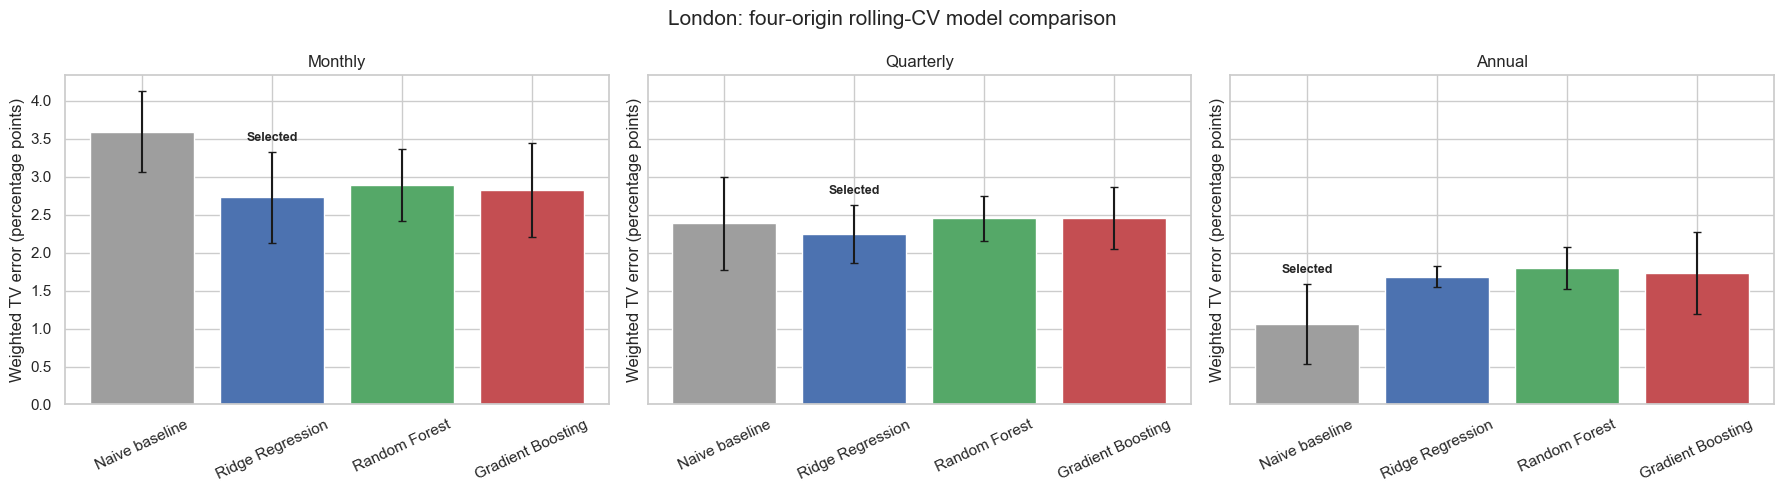

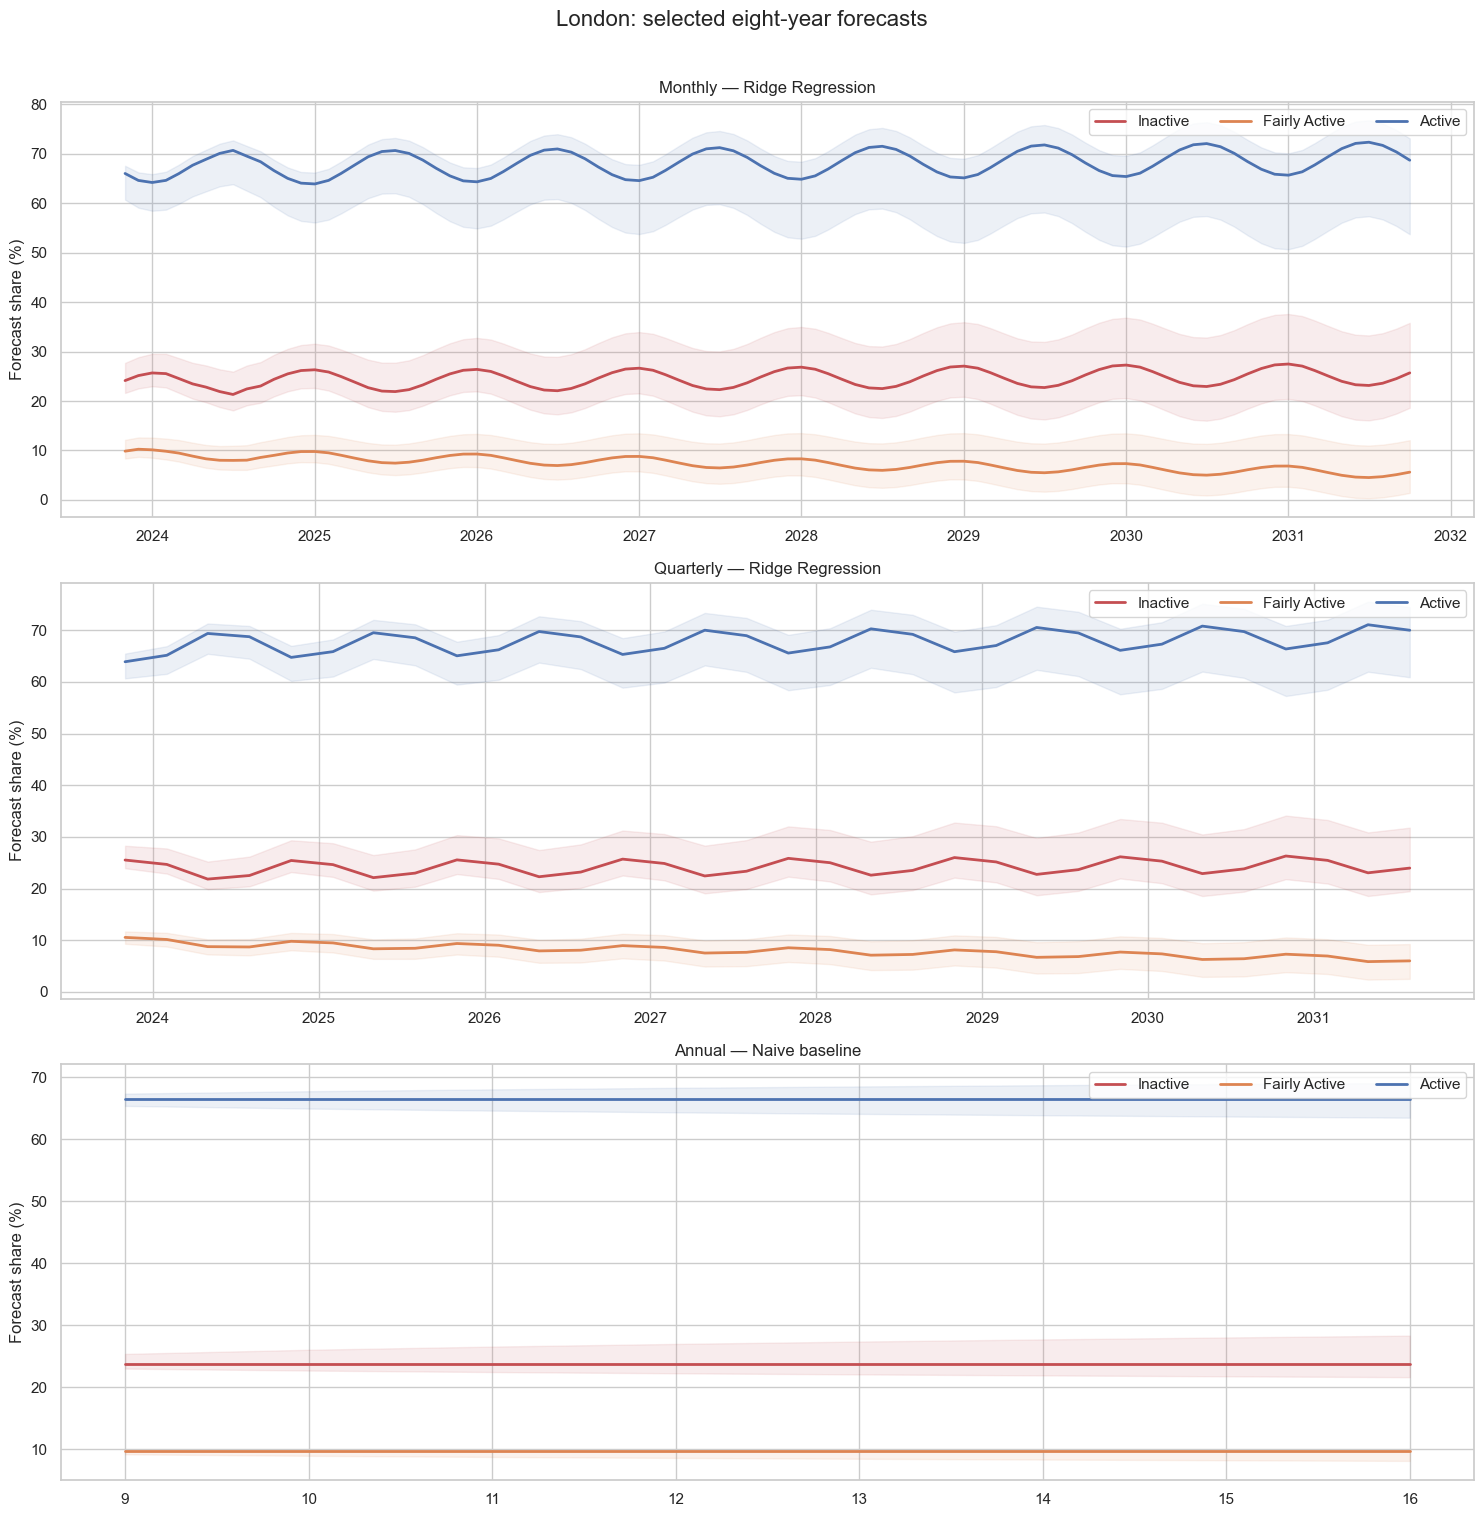

,frequency,model,Inactive,Fairly Active,Active
135,Annual,Naive baseline,23.8,9.8,66.4
127,Quarterly,Ridge Regression,24.0,6.0,70.0
95,Monthly,Ridge Regression,25.7,5.6,68.7


In [5]:
# Compare London models and plot the selected eight-year compositions.
def plot_model_comparison(level):
    """Show the four historical model errors for each frequency."""
    local = model_summary.loc[model_summary['geographic_level'].eq(level)].copy()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for axis, frequency in zip(axes, FREQUENCIES):
        subset = local.loc[local['frequency'].eq(frequency)].set_index('model').reindex(MODELS).reset_index()
        colors = [MODEL_COLORS[name] for name in subset['model']]
        axis.bar(subset['model'], subset['mean'] * 100, yerr=subset['se'] * 100,
                 color=colors, capsize=3)
        chosen = subset.loc[subset['selected']].iloc[0]
        axis.text(chosen.name, chosen['mean'] * 100 + chosen['se'] * 100 + .15,
                  'Selected', ha='center', fontsize=9, fontweight='bold')
        # Calculate and store axis.set(title for the following analysis step.
        axis.set(title=frequency, xlabel='', ylabel='Weighted TV error (percentage points)')
        axis.tick_params(axis='x', rotation=25)
    # Create or format the figure for this comparison.
    fig.suptitle(f'{level}: four-origin rolling-CV model comparison', fontsize=15)
    fig.tight_layout()
    plt.show()


# Define future axis values once so the same rule is reused consistently.
def future_axis_values(frame, frequency):
    """Return readable horizontal values for monthly, quarterly or annual forecasts."""
    config = FREQUENCY_CONFIG[frequency]
    if frequency == 'Monthly':
        start = panels[('London', frequency)][config['date']].max()
        return pd.DatetimeIndex([start + pd.DateOffset(months=int(step)) for step in frame['future_step']])
    if frequency == 'Quarterly':
        start = panels[('London', frequency)][config['date']].max()
        return pd.DatetimeIndex([start + pd.DateOffset(months=3 * int(step)) for step in frame['future_step']])
    # Return the completed result to the calling analysis step.
    return frame[config['time']]


# Apply the next transformation to the prepared analysis object.
plot_model_comparison('London')
fig, axes = plt.subplots(3, 1, figsize=(15, 15))
for axis, frequency in zip(axes, FREQUENCIES):
    future = selected_forecasts.loc[
        selected_forecasts['geographic_level'].eq('London')
        & selected_forecasts['frequency'].eq(frequency)
    ].sort_values('future_step')
    x = future_axis_values(future, frequency)
    for target, color in zip(TARGETS, ['#C44E52', '#DD8452', '#4C72B0']):
        axis.plot(x, future[f'predicted_{target}'] * 100, color=color, linewidth=2,
                  label=TARGET_LABELS[target])
        axis.fill_between(x, future[f'lower_{target}'] * 100,
                          future[f'upper_{target}'] * 100, color=color, alpha=.10)
    # Calculate and store selected for the following analysis step.
    selected = selection_table.query("Geography == 'London' and Frequency == @frequency")['Selected model'].iloc[0]
    axis.set(title=f'{frequency} — {selected}', xlabel='', ylabel='Forecast share (%)')
    axis.legend(ncol=3)
# Create or format the figure for this comparison.
fig.suptitle('London: selected eight-year forecasts', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

london_endpoints = selected_forecasts.loc[
    selected_forecasts['geographic_level'].eq('London')
].sort_values('future_step').groupby('frequency').tail(1)
# Display the finished visual or summary for interpretation.
display(london_endpoints[['frequency', 'model', *[f'predicted_{target}' for target in TARGETS]]]
        .rename(columns={f'predicted_{target}': TARGET_LABELS[target] for target in TARGETS})
        .assign(**{label: lambda frame, label=label: frame[label] * 100 for label in TARGET_LABELS.values()})
        .round(1))


## 4. Inner and Outer London

The four model definitions are applied consistently across geographic levels. Future charts focus on Active because it makes the Inner–Outer difference easiest to read; the endpoint table reports all three predicted states. Separate lines are predictions for the two areas, not confidence bounds around one London value.


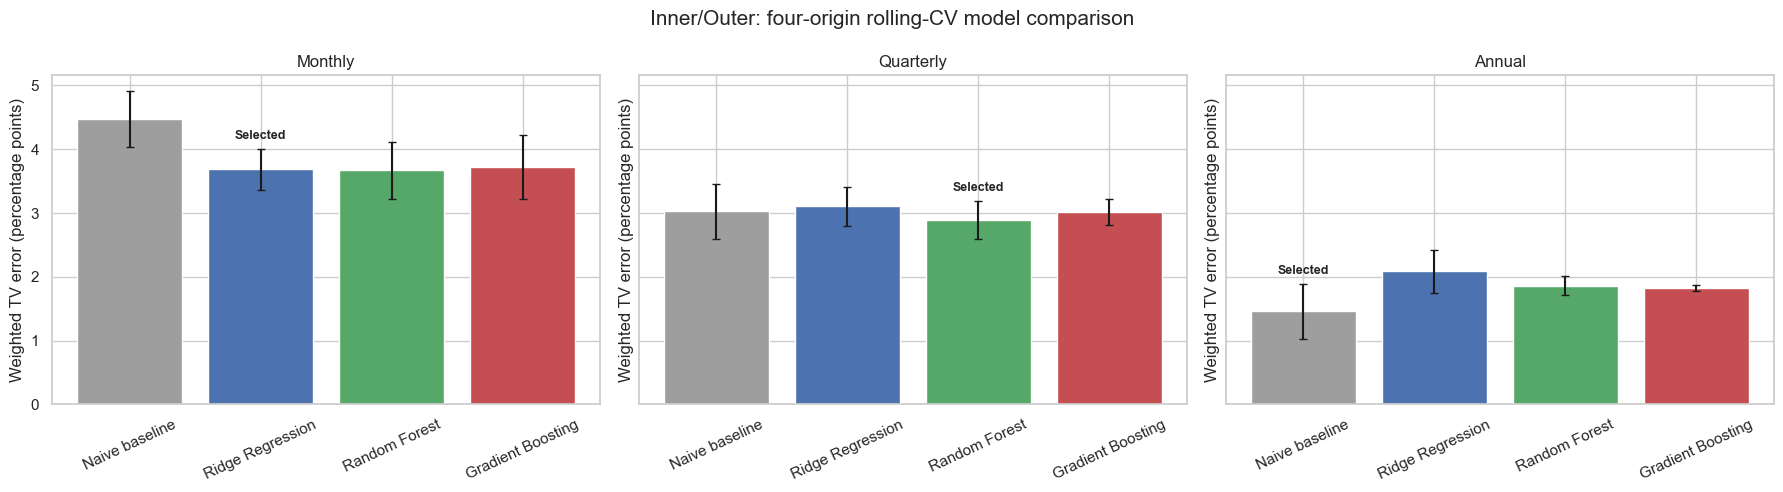

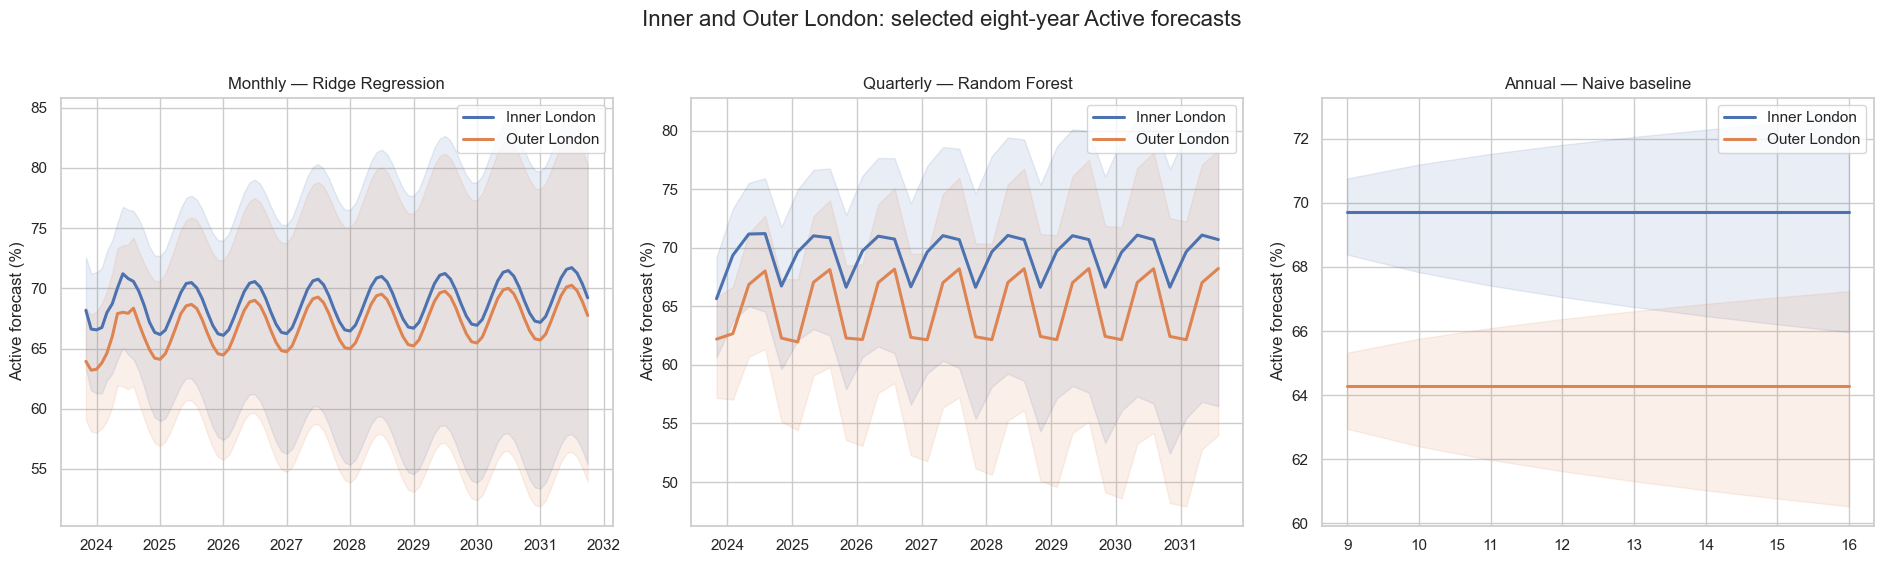

,frequency,geography_name,model,Inactive,Fairly Active,Active
399,Annual,Inner London,Naive baseline,21.4,8.9,69.7
407,Annual,Outer London,Naive baseline,25.4,10.4,64.3
391,Quarterly,Outer London,Random Forest,21.6,10.1,68.2
359,Quarterly,Inner London,Random Forest,20.1,9.2,70.7
231,Monthly,Inner London,Ridge Regression,23.9,6.9,69.2
327,Monthly,Outer London,Ridge Regression,25.1,7.2,67.7


In [6]:
# Compare Inner/Outer models and show the future Active paths.
plot_model_comparison('Inner/Outer')
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for axis, frequency in zip(axes, FREQUENCIES):
    future = selected_forecasts.loc[
        selected_forecasts['geographic_level'].eq('Inner/Outer')
        & selected_forecasts['frequency'].eq(frequency)
    ].copy()
    for geography_name, color in [('Inner London', '#4C72B0'), ('Outer London', '#DD8452')]:
        line = future.loc[future['geography_name'].eq(geography_name)].sort_values('future_step')
        x = future_axis_values(line, frequency)
        axis.plot(x, line['predicted_active_rate'] * 100, marker=None,
                  linewidth=2.2, color=color, label=geography_name)
        axis.fill_between(x, line['lower_active_rate'] * 100,
                          line['upper_active_rate'] * 100, color=color, alpha=.12)
    # Calculate and store selected for the following analysis step.
    selected = selection_table.query("Geography == 'Inner/Outer' and Frequency == @frequency")['Selected model'].iloc[0]
    axis.set(title=f'{frequency} — {selected}', xlabel='', ylabel='Active forecast (%)')
    axis.legend()
# Create or format the figure for this comparison.
fig.suptitle('Inner and Outer London: selected eight-year Active forecasts', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

inner_outer_endpoints = selected_forecasts.loc[
    selected_forecasts['geographic_level'].eq('Inner/Outer')
].sort_values('future_step').groupby(
    ['frequency', 'geography_name']
).tail(1)
# Display the finished visual or summary for interpretation.
display(inner_outer_endpoints[[
    'frequency', 'geography_name', 'model',
    *[f'predicted_{target}' for target in TARGETS],
]].rename(columns={f'predicted_{target}': TARGET_LABELS[target] for target in TARGETS})
  .assign(**{label: lambda frame, label=label: frame[label] * 100 for label in TARGET_LABELS.values()})
  .round(1))


## 5. London boroughs

The borough models pool all 32 areas while retaining borough identity. This gives the machine-learning methods substantially more training observations than the London annual task.

For readability, future monthly and quarterly predictions are averaged into eight forecast years. Each heatmap comes from its corresponding monthly, quarterly or annual model; no frequency is substituted for another. The map uses the final year averaged from the selected quarterly model as supplementary higher-frequency evidence.


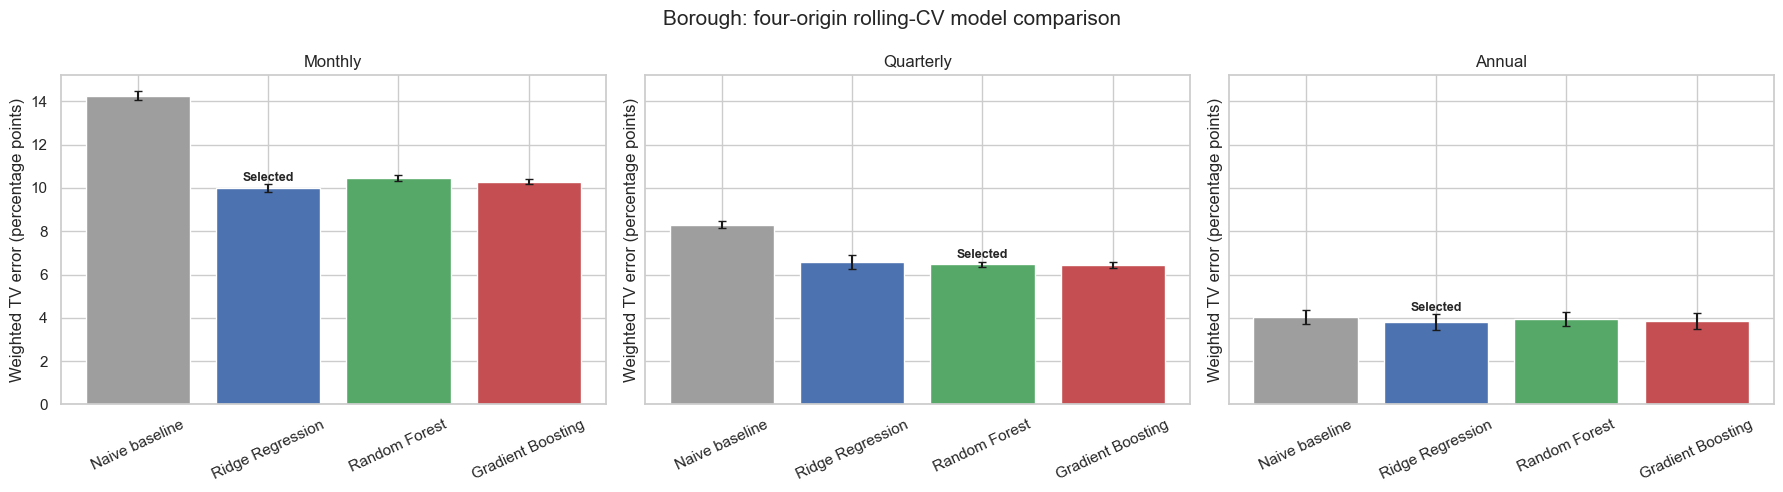

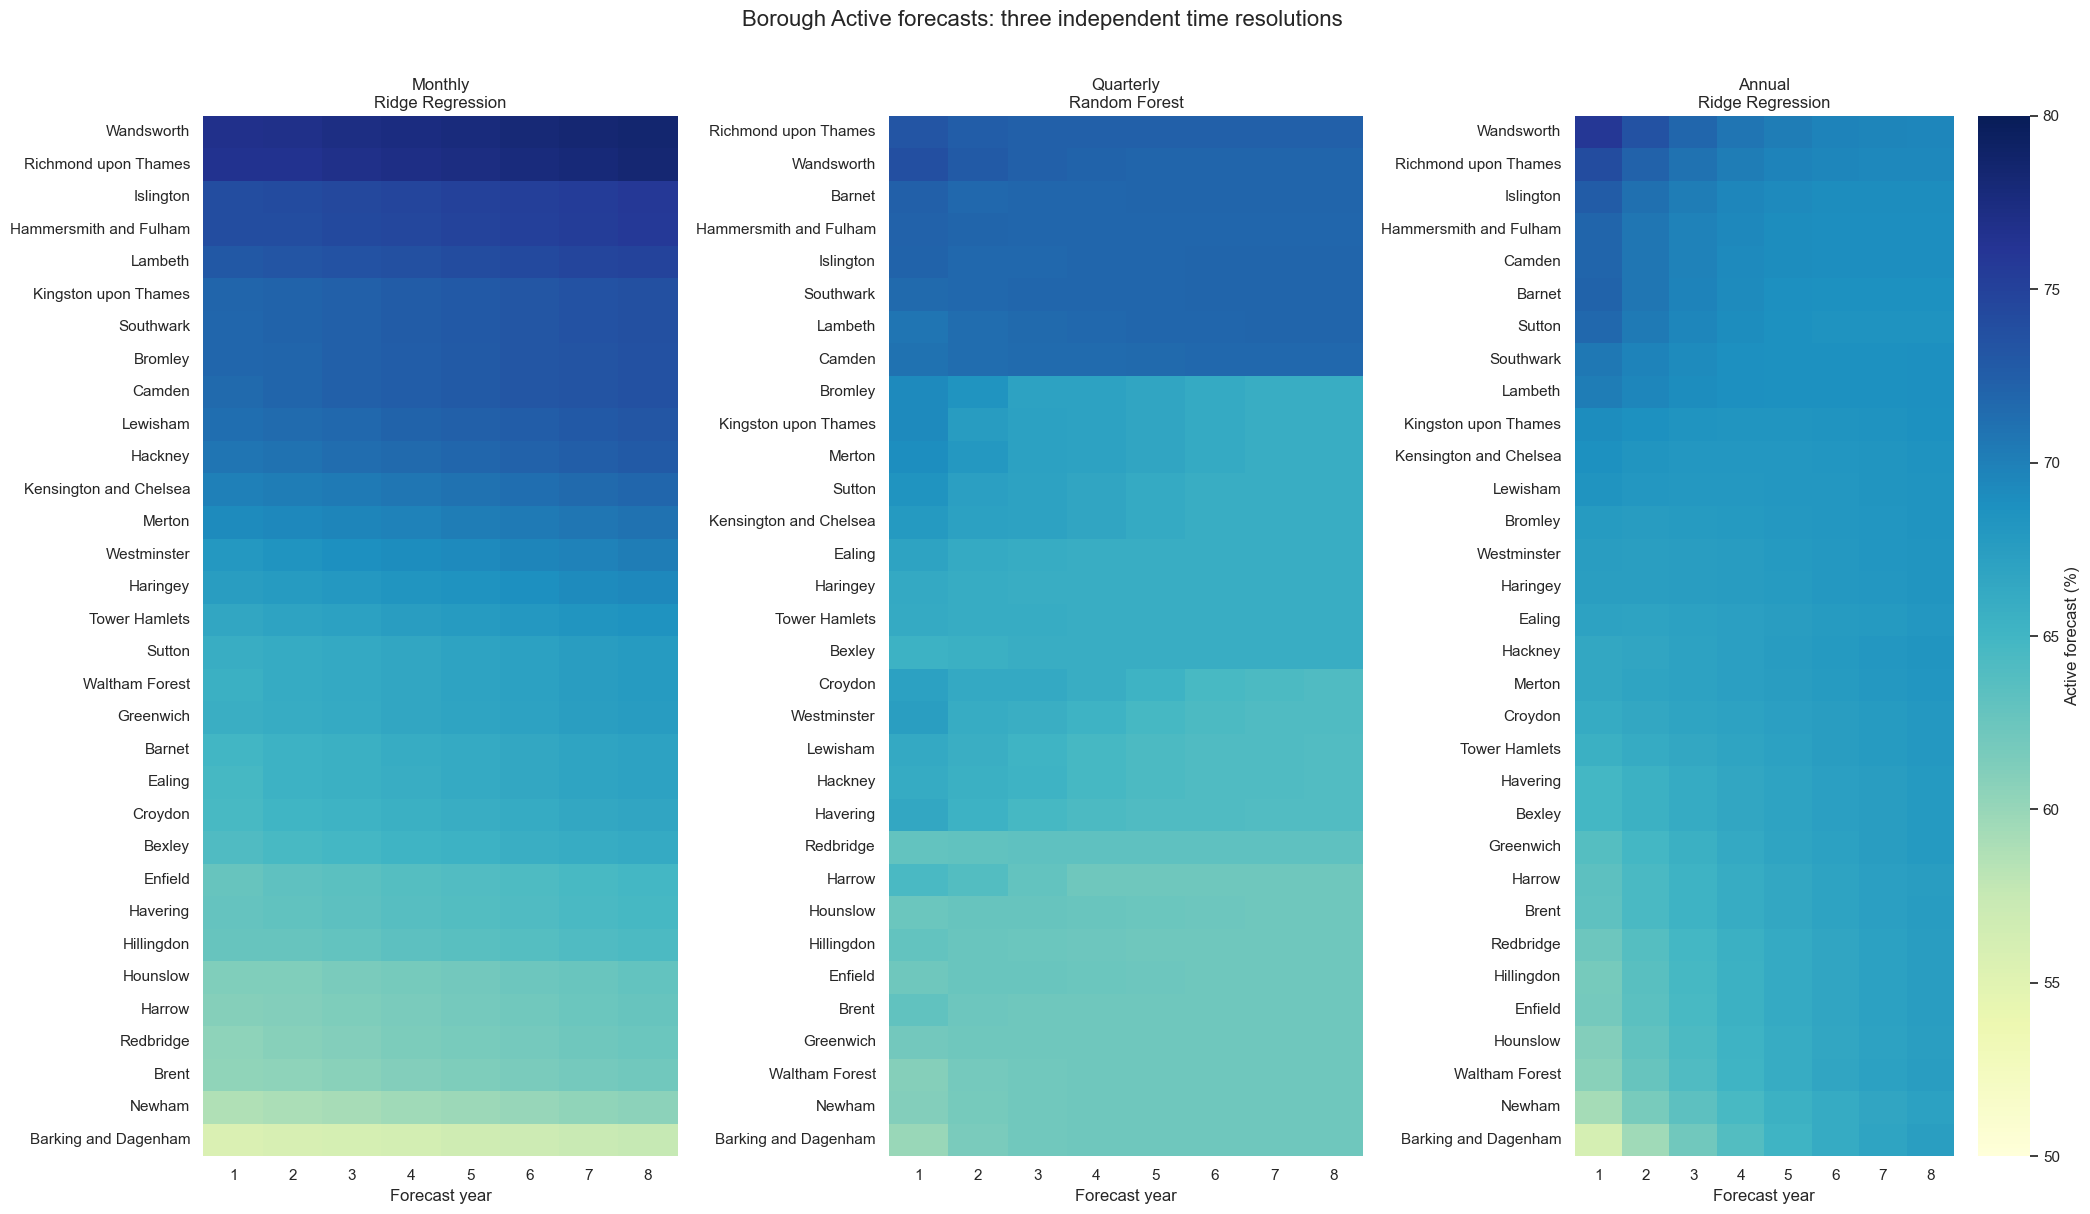

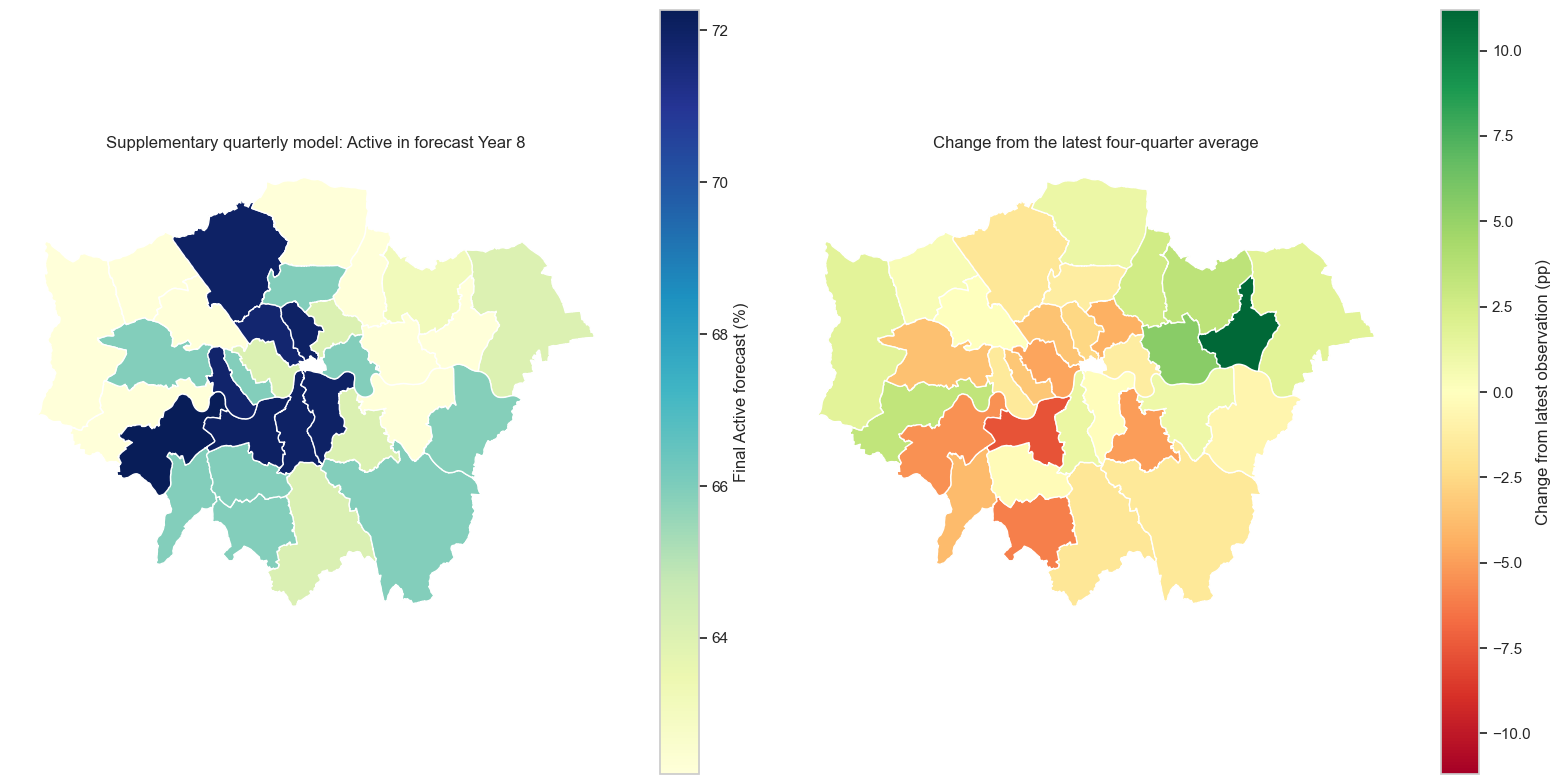

In [7]:
# Compare borough models and display annualised Active forecasts for all 32 boroughs.
plot_model_comparison('Borough')

def annualise_future(frame, frequency):
    """Convert future steps to forecast years for an interpretable borough heatmap."""
    periods = FREQUENCY_CONFIG[frequency]['periods_per_year']
    result = frame.copy()
    result['forecast_year'] = ((result['future_step'] - 1) // periods + 1).astype(int)
    return result.groupby(['geography_code', 'geography_name', 'forecast_year'], as_index=False)[
        'predicted_active_rate'
    ].mean()


# Build the figure that presents the comparison clearly.
fig, axes = plt.subplots(1, 3, figsize=(21, 12))
for axis, frequency in zip(axes, FREQUENCIES):
    future = selected_forecasts.loc[
        selected_forecasts['geographic_level'].eq('Borough')
        & selected_forecasts['frequency'].eq(frequency)
    ]
    annualised = annualise_future(future, frequency)
    matrix = annualised.pivot(
        index='geography_name', columns='forecast_year', values='predicted_active_rate'
    ) * 100
    # Calculate and store matrix for the following analysis step.
    matrix = matrix.loc[matrix.mean(axis=1).sort_values(ascending=False).index]
    sns.heatmap(matrix, cmap='YlGnBu', vmin=50, vmax=80, ax=axis,
                cbar=frequency == 'Annual', cbar_kws={'label': 'Active forecast (%)'})
    selected = selection_table.query("Geography == 'Borough' and Frequency == @frequency")['Selected model'].iloc[0]
    axis.set(title=f'{frequency}\n{selected}', xlabel='Forecast year', ylabel='')
# Create or format the figure for this comparison.
fig.suptitle('Borough Active forecasts: three independent time resolutions', fontsize=16, y=1.01)
fig.tight_layout()
plt.show()

quarterly_final_year = annualise_future(
    selected_forecasts.loc[
        selected_forecasts['geographic_level'].eq('Borough')
        & selected_forecasts['frequency'].eq('Quarterly')
    ],
    'Quarterly',
).loc[lambda frame: frame['forecast_year'].eq(8)].copy()
# Define the time split or forecast horizon used for evaluation.
latest_quarter = panels[('Borough', 'Quarterly')]['quarter_index'].max()
latest_active = panels[('Borough', 'Quarterly')].loc[
    lambda frame: frame['quarter_index'].gt(latest_quarter - 4)
].groupby('geography_code', as_index=False)['active_rate'].mean()
quarterly_final_year = quarterly_final_year.merge(
    latest_active, on='geography_code', validate='one_to_one'
)
# Calculate and store quarterly final year['change pp'] for the following analysis step.
quarterly_final_year['change_pp'] = (
    quarterly_final_year['predicted_active_rate'] - quarterly_final_year['active_rate']
) * 100
quarterly_final_year['predicted_active_pct'] = quarterly_final_year['predicted_active_rate'] * 100
forecast_map = borough_boundaries.merge(
    quarterly_final_year, left_on='gss_code', right_on='geography_code', validate='one_to_one'
)

# Build the figure that presents the comparison clearly.
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
forecast_map.plot(column='predicted_active_pct', cmap='YlGnBu', edgecolor='white', legend=True,
                  legend_kwds={'label': 'Final Active forecast (%)'}, ax=axes[0])
axes[0].set_title('Supplementary quarterly model: Active in forecast Year 8')
limit = max(abs(forecast_map['change_pp'].min()), abs(forecast_map['change_pp'].max()))
forecast_map.plot(column='change_pp', cmap='RdYlGn', vmin=-limit, vmax=limit,
                  edgecolor='white', legend=True,
                  legend_kwds={'label': 'Change from latest observation (pp)'}, ax=axes[1])
# Create or format the figure for this comparison.
axes[1].set_title('Change from the latest four-quarter average')
for axis in axes:
    axis.set_axis_off()
fig.tight_layout()
plt.show()


## 6. Rolling-origin selection and Year 8 test

The model matrix records decisions made from the mean of the four rolling validation folds using activity-history features only. The external experiment above is deliberately separate and does not alter the specification. Weighted TV remains the primary selection criterion; weighted MAE, weighted RMSE and outcome-specific MAE are reported as transparent diagnostics. For a three-part composition, weighted MAE is exactly two-thirds of TV, so RMSE and the three outcome columns provide the genuinely additional comparison.

After all choices are frozen, every family is refitted on Years 1–7 and evaluated on Year 8. This gives a genuine out-of-sample comparison, but the official winner is not changed after seeing Year 8. The overall model chart summarises mean rolling-CV performance relative to Naive, and the parameter audit identifies selected values that sit at a search boundary or were held fixed.


Frequency,Monthly,Quarterly,Annual
Geography,,,
London,Ridge Regression,Ridge Regression,Naive baseline
Inner/Outer,Ridge Regression,Random Forest,Naive baseline
Borough,Ridge Regression,Random Forest,Ridge Regression


,Geography,Frequency,Selected model,Selected parameters
0,London,Monthly,Ridge Regression,{'alpha': 10.0}
1,London,Quarterly,Ridge Regression,{'alpha': 10.0}
2,London,Annual,Naive baseline,{}
3,Inner/Outer,Monthly,Ridge Regression,{'alpha': 100.0}
4,Inner/Outer,Quarterly,Random Forest,"{'n_estimators': 300, 'max_depth': 6, 'min_lea..."
5,Inner/Outer,Annual,Naive baseline,{}
6,Borough,Monthly,Ridge Regression,{'alpha': 0.1}
7,Borough,Quarterly,Random Forest,"{'n_estimators': 300, 'max_depth': 6, 'min_lea..."
8,Borough,Annual,Ridge Regression,{'alpha': 100.0}


,Geography,Frequency,Official external variables
0,London,Monthly,None — experiment only
1,London,Quarterly,None — experiment only
2,London,Annual,None — experiment only
3,Inner/Outer,Monthly,None — experiment only
4,Inner/Outer,Quarterly,None — experiment only
5,Inner/Outer,Annual,None — experiment only
6,Borough,Monthly,None — experiment only
7,Borough,Quarterly,None — experiment only
8,Borough,Annual,None — experiment only


,Geography,Frequency,Model,Official CV winner,Weighted TV (pp),Weighted MAE (pp),Weighted RMSE (pp),Inactive MAE (pp),Fairly Active MAE (pp),Active MAE (pp)
0,London,Monthly,Naive baseline,False,3.595,2.397,2.980,2.608,1.453,3.128
1,London,Monthly,Ridge Regression,True,2.728,1.819,2.436,1.850,1.223,2.382
2,London,Monthly,Random Forest,False,2.894,1.929,2.444,1.910,1.304,2.572
3,London,Monthly,Gradient Boosting,False,2.826,1.884,2.442,1.906,1.384,2.362
4,London,Quarterly,Naive baseline,False,2.388,1.592,1.979,1.681,1.062,2.032
5,London,Quarterly,Ridge Regression,True,2.247,1.498,1.892,1.673,0.899,1.922
6,London,Quarterly,Random Forest,False,2.455,1.636,2.116,1.637,1.100,2.173
7,London,Quarterly,Gradient Boosting,False,2.455,1.637,2.126,1.694,1.062,2.155
8,London,Annual,Naive baseline,True,1.061,0.707,0.780,0.947,0.295,0.880
9,London,Annual,Ridge Regression,False,1.685,1.123,1.256,1.046,1.315,1.009


,Model,Mean TV rank,Mean RMSE rank,Official task wins,Lowest TV tasks,Lowest RMSE tasks,Combined mean rank
0,Ridge Regression,2.11,2.22,5,4,3,2.17
1,Gradient Boosting,2.33,2.11,0,1,3,2.22
2,Random Forest,2.56,2.89,2,2,1,2.72
3,Naive baseline,3.00,2.78,2,2,2,2.89


Best overall family across the nine rolling-CV tasks: Ridge Regression


,Geography,Frequency,Selected model,External design,Test TV
0,London,Monthly,Ridge Regression,Base history only,2.25
1,London,Quarterly,Ridge Regression,Base history only,1.66
2,London,Annual,Naive baseline,Base history only,0.66
3,Inner/Outer,Monthly,Ridge Regression,Base history only,3.29
4,Inner/Outer,Quarterly,Random Forest,Base history only,2.36
5,Inner/Outer,Annual,Naive baseline,Base history only,0.70
6,Borough,Monthly,Ridge Regression,Base history only,9.86
7,Borough,Quarterly,Random Forest,Base history only,6.97
8,Borough,Annual,Ridge Regression,Base history only,3.99


,Geography,Frequency,Model,Official CV winner,Weighted TV (pp),Weighted MAE (pp),Weighted RMSE (pp),Inactive MAE (pp),Fairly Active MAE (pp),Active MAE (pp)
0,London,Monthly,Naive baseline,False,2.506,1.671,2.090,2.072,1.218,1.723
1,London,Monthly,Ridge Regression,True,2.247,1.498,1.965,1.780,0.978,1.736
2,London,Monthly,Random Forest,False,2.245,1.497,1.997,1.850,0.918,1.722
3,London,Monthly,Gradient Boosting,False,2.584,1.723,2.332,2.119,0.974,2.074
4,London,Quarterly,Naive baseline,False,1.419,0.946,1.172,1.234,0.979,0.625
5,London,Quarterly,Ridge Regression,True,1.657,1.105,1.443,1.524,0.469,1.322
6,London,Quarterly,Random Forest,False,1.723,1.149,1.381,1.095,0.970,1.381
7,London,Quarterly,Gradient Boosting,False,1.661,1.107,1.235,1.312,0.713,1.297
8,London,Annual,Naive baseline,True,0.662,0.442,0.493,0.662,0.518,0.145
9,London,Annual,Ridge Regression,False,1.581,1.054,1.120,0.701,1.581,0.880


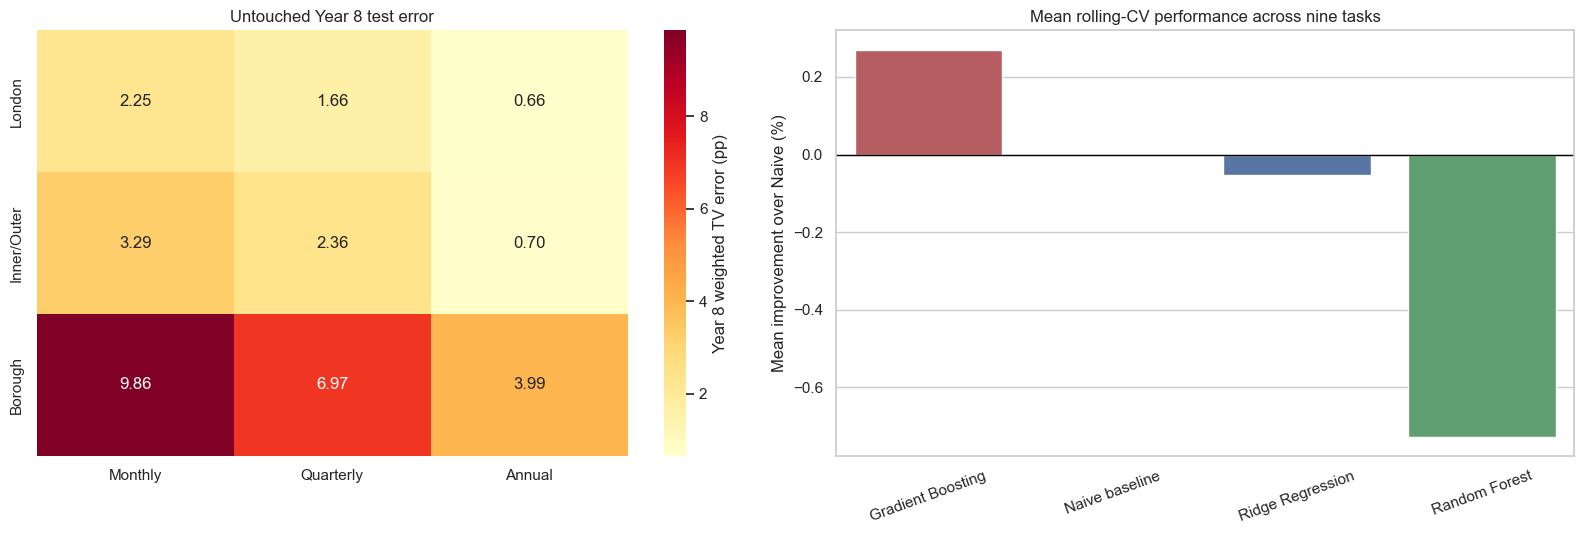

,model,mean_skill_pct,tasks_beating_naive
0,Gradient Boosting,0.3,6
1,Naive baseline,0.0,0
3,Ridge Regression,-0.1,6
2,Random Forest,-0.7,6


,Model,Parameter,Tested values,Task-specific family winners,Boundary/fixed selections
0,Gradient Boosting,learning_rate,"[0.01, 0.025, 0.05, 0.1]",9,3
1,Gradient Boosting,max_depth,"[2, 1, 3]",9,5
2,Gradient Boosting,min_leaf_fraction,[0.01],9,9
3,Gradient Boosting,n_estimators,"[500, 200, 100, 50]",9,3
4,Random Forest,max_depth,"[6, 10, None]",9,1
5,Random Forest,max_features,"[0.5, 0.8, 1.0]",9,8
6,Random Forest,min_leaf_fraction,"[0.02, 0.01, 0.005]",9,6
7,Random Forest,n_estimators,[300],9,9
8,Ridge Regression,alpha,"[0.1, 1.0, 10.0, 100.0, 1000.0]",9,3


,Model,Parameter,Known limitation / interpretation
0,Ridge Regression,alpha,Broad logarithmic range; boundary winners shou...
1,Random Forest,n_estimators,Fixed at 300 for Monte Carlo stability; it con...
2,Random Forest,depth / leaf / max_features,"Five profiles are tested, not a full factorial..."
3,Gradient Boosting,learning_rate / n_estimators,"Paired to keep boosting budget comparable, so ..."
4,Gradient Boosting,min_leaf_fraction,Fixed at 1%; depth and shrinkage receive stron...
5,RF and GB,random_state,Seed 2026 provides exact reproducibility; 300-...


In [8]:
# Report the frozen specification, untouched test error and validation-wide comparison.
selection_matrix = selection_table.pivot(
    index='Geography', columns='Frequency', values='Selected model'
).reindex(index=LEVELS, columns=FREQUENCIES)
display(selection_matrix)
display(selection_table[[
    'Geography', 'Frequency', 'Selected model', 'Selected parameters'
]])
display(selection_table[['Geography', 'Frequency']].assign(
    **{'Official external variables': 'None — experiment only'}
))

# Compare all four family winners on the same rolling folds and metrics.
metric_columns = ['weighted_tv', 'weighted_mae', 'weighted_rmse']
metric_labels = {
    'weighted_tv': 'Weighted TV (pp)',
    'weighted_mae': 'Weighted MAE (pp)',
    'weighted_rmse': 'Weighted RMSE (pp)',
    'inactive_rate_mae': 'Inactive MAE (pp)',
    'fairly_active_rate_mae': 'Fairly Active MAE (pp)',
    'active_rate_mae': 'Active MAE (pp)',
}
comparison_columns = [*metric_columns, *[f'{target}_mae' for target in TARGETS]]
rolling_metrics_display = rolling_model_metrics[[
    'Geography', 'Frequency', 'model', 'selected', *comparison_columns
]].copy()
rolling_metrics_display[comparison_columns] *= 100
display(rolling_metrics_display.rename(columns={
    'model': 'Model', 'selected': 'Official CV winner', **metric_labels,
}).round(3))

# Rank by the primary TV and the non-redundant RMSE diagnostic.
ranking_source = rolling_model_metrics.copy()
for metric in ('weighted_tv', 'weighted_rmse'):
    ranking_source[f'{metric}_rank'] = ranking_source.groupby([
        'Geography', 'Frequency'
    ])[metric].rank(method='average')
overall_metric_ranking = ranking_source.groupby('model', as_index=False).agg(
    mean_tv_rank=('weighted_tv_rank', 'mean'),
    mean_rmse_rank=('weighted_rmse_rank', 'mean'),
    tasks_selected=('selected', 'sum'),
    tasks_lowest_tv=('weighted_tv_rank', lambda values: int((values == 1).sum())),
    tasks_lowest_rmse=('weighted_rmse_rank', lambda values: int((values == 1).sum())),
)
overall_metric_ranking['combined_mean_rank'] = overall_metric_ranking[[
    'mean_tv_rank', 'mean_rmse_rank'
]].mean(axis=1)
overall_metric_ranking = overall_metric_ranking.sort_values([
    'combined_mean_rank', 'mean_tv_rank', 'model'
]).reset_index(drop=True)
display(overall_metric_ranking.rename(columns={
    'model': 'Model', 'mean_tv_rank': 'Mean TV rank',
    'mean_rmse_rank': 'Mean RMSE rank', 'tasks_selected': 'Official task wins',
    'tasks_lowest_tv': 'Lowest TV tasks',
    'tasks_lowest_rmse': 'Lowest RMSE tasks',
    'combined_mean_rank': 'Combined mean rank',
}).round(2))
best_overall_model = overall_metric_ranking.iloc[0]['model']
print(f'Best overall family across the nine rolling-CV tasks: {best_overall_model}')

# Define the time split or forecast horizon used for evaluation.
test_matrix = test_summary.pivot(
    index='Geography', columns='Frequency', values='Test TV'
).reindex(index=LEVELS, columns=FREQUENCIES) * 100
display(test_summary[['Geography', 'Frequency', 'Selected model', 'External design', 'Test TV']]
        .assign(**{'Test TV': lambda frame: frame['Test TV'] * 100}).round(2))

# Report every frozen family on Year 8; the flag preserves the pre-test decision.
year8_metrics_display = all_test_model_metrics[[
    'Geography', 'Frequency', 'model', 'official_cv_winner', *comparison_columns
]].copy()
year8_metrics_display[comparison_columns] *= 100
display(year8_metrics_display.rename(columns={
    'model': 'Model', 'official_cv_winner': 'Official CV winner', **metric_labels,
}).round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
# Add this result to the current visual comparison.
sns.heatmap(test_matrix, cmap='YlOrRd', annot=True, fmt='.2f',
            cbar_kws={'label': 'Year 8 weighted TV error (pp)'}, ax=axes[0])
axes[0].set(title='Untouched Year 8 test error', xlabel='', ylabel='')

relative = model_summary.merge(
    model_summary.loc[model_summary['model'].eq('Naive baseline'),
                      ['geographic_level', 'frequency', 'mean']].rename(columns={'mean': 'naive_error'}),
    on=['geographic_level', 'frequency'], validate='many_to_one'
)
# Calculate and store relative['error relative to naive'] for the following analysis step.
relative['error_relative_to_naive'] = relative['mean'] / relative['naive_error']
overall_models = relative.groupby('model', as_index=False).agg(
    mean_relative_error=('error_relative_to_naive', 'mean'),
    tasks_beating_naive=('error_relative_to_naive', lambda values: int((values < 1).sum())),
)
overall_models['mean_skill_pct'] = (1 - overall_models['mean_relative_error']) * 100
overall_models = overall_models.sort_values('mean_relative_error')
# Add this result to the current visual comparison.
sns.barplot(data=overall_models, x='model', y='mean_skill_pct',
            palette=MODEL_COLORS, hue='model', legend=False, ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set(title='Mean rolling-CV performance across nine tasks', xlabel='',
            ylabel='Mean improvement over Naive (%)')
axes[1].tick_params(axis='x', rotation=20)
fig.tight_layout()
# Display the finished visual or summary for interpretation.
plt.show()
display(overall_models[['model', 'mean_skill_pct', 'tasks_beating_naive']].round(1))

# Audit boundary hits and fixed values in the selected within-family parameters.
boundary_rows = []
for _, selected_row in selected_parameter_table.iterrows():
    model_name = selected_row['model']
    for parameter, value in selected_row['parameter_values'].items():
        tested_values = list(dict.fromkeys(
            candidate[parameter] for candidate in MODEL_PARAMETER_GRID[model_name]
            if parameter in candidate
        ))
        if len(tested_values) == 1:
            position = 'Fixed; not sensitivity-tested'
        elif value is None:
            position = 'Unrestricted option'
        elif all(isinstance(item, (int, float)) and item is not None
                 for item in tested_values):
            if value == min(tested_values):
                position = 'Lower search boundary'
            elif value == max(tested_values):
                position = 'Upper search boundary'
            else:
                position = 'Interior tested value'
        else:
            position = 'Tested option'
        boundary_rows.append({
            'Geography': selected_row['Geography'],
            'Frequency': selected_row['Frequency'], 'Model': model_name,
            'Parameter': parameter, 'Selected value': value,
            'Tested values': repr(tested_values), 'Position': position,
        })
parameter_boundary_audit = pd.DataFrame(boundary_rows)
parameter_boundary_summary = parameter_boundary_audit.groupby([
    'Model', 'Parameter', 'Tested values'
], as_index=False).agg(
    family_winners=('Selected value', 'size'),
    boundary_or_fixed=('Position', lambda values: int(values.isin([
        'Lower search boundary', 'Upper search boundary',
        'Unrestricted option', 'Fixed; not sensitivity-tested',
    ]).sum())),
)
display(parameter_boundary_summary.rename(columns={
    'family_winners': 'Task-specific family winners',
    'boundary_or_fixed': 'Boundary/fixed selections',
}))

parameter_limitations = pd.DataFrame([
    ['Ridge Regression', 'alpha',
     'Broad logarithmic range; boundary winners should be checked with a wider range in future work.'],
    ['Random Forest', 'n_estimators',
     'Fixed at 300 for Monte Carlo stability; it controls precision/runtime rather than regularisation strength.'],
    ['Random Forest', 'depth / leaf / max_features',
     'Five profiles are tested, not a full factorial grid, so separate interaction effects are not identified.'],
    ['Gradient Boosting', 'learning_rate / n_estimators',
     'Paired to keep boosting budget comparable, so their separate effects are not identified.'],
    ['Gradient Boosting', 'min_leaf_fraction',
     'Fixed at 1%; depth and shrinkage receive stronger sensitivity testing than leaf size.'],
    ['RF and GB', 'random_state',
     'Seed 2026 provides exact reproducibility; 300-tree forests limit Monte Carlo variation.'],
], columns=['Model', 'Parameter', 'Known limitation / interpretation'])
display(parameter_limitations)


## 7. What information drives the quarterly forecasts?

The following feature-ablation diagnostic uses the quarterly model parameters selected across all four rolling folds and evaluates predictor groups on Year 7. Year 8 is reserved for final testing, so the diagnostic is interpreted conditionally rather than as a second independent validation exercise.

The first figure removes one predictor group at a time, refits the model and reports the change in weighted TV error. A positive value means that error rises when the group is removed, so that group helped the Year 7 forecast. A negative value means the reduced model performed slightly better. All variants use the same warm-up sample to make the comparison fair.

The second figure shows the largest standardized Ridge coefficients for the Active equation. Their signs describe predictive associations, not causal effects. Because lagged activity variables are correlated and predictions are subsequently rescaled to sum to 100%, individual coefficients should be read together with the more robust group-ablation result. External variables are not shown because none was adopted in the official specification.


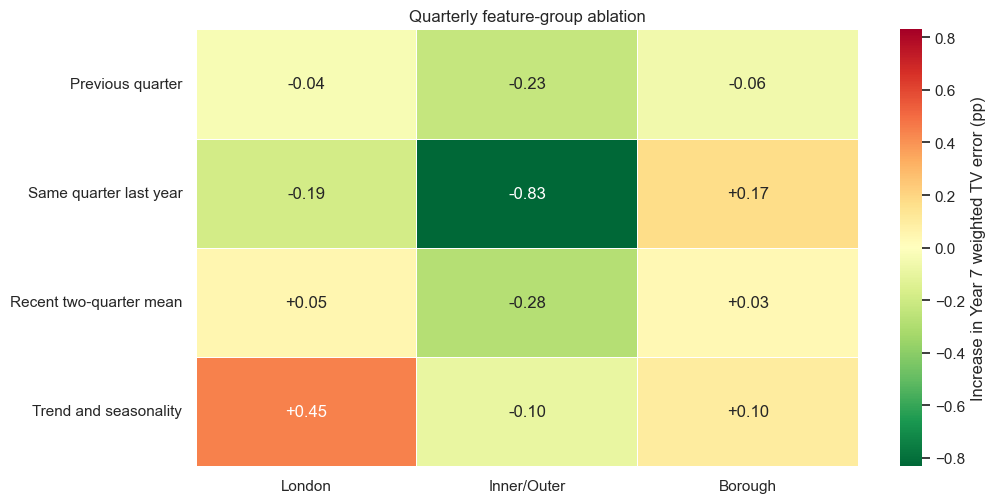

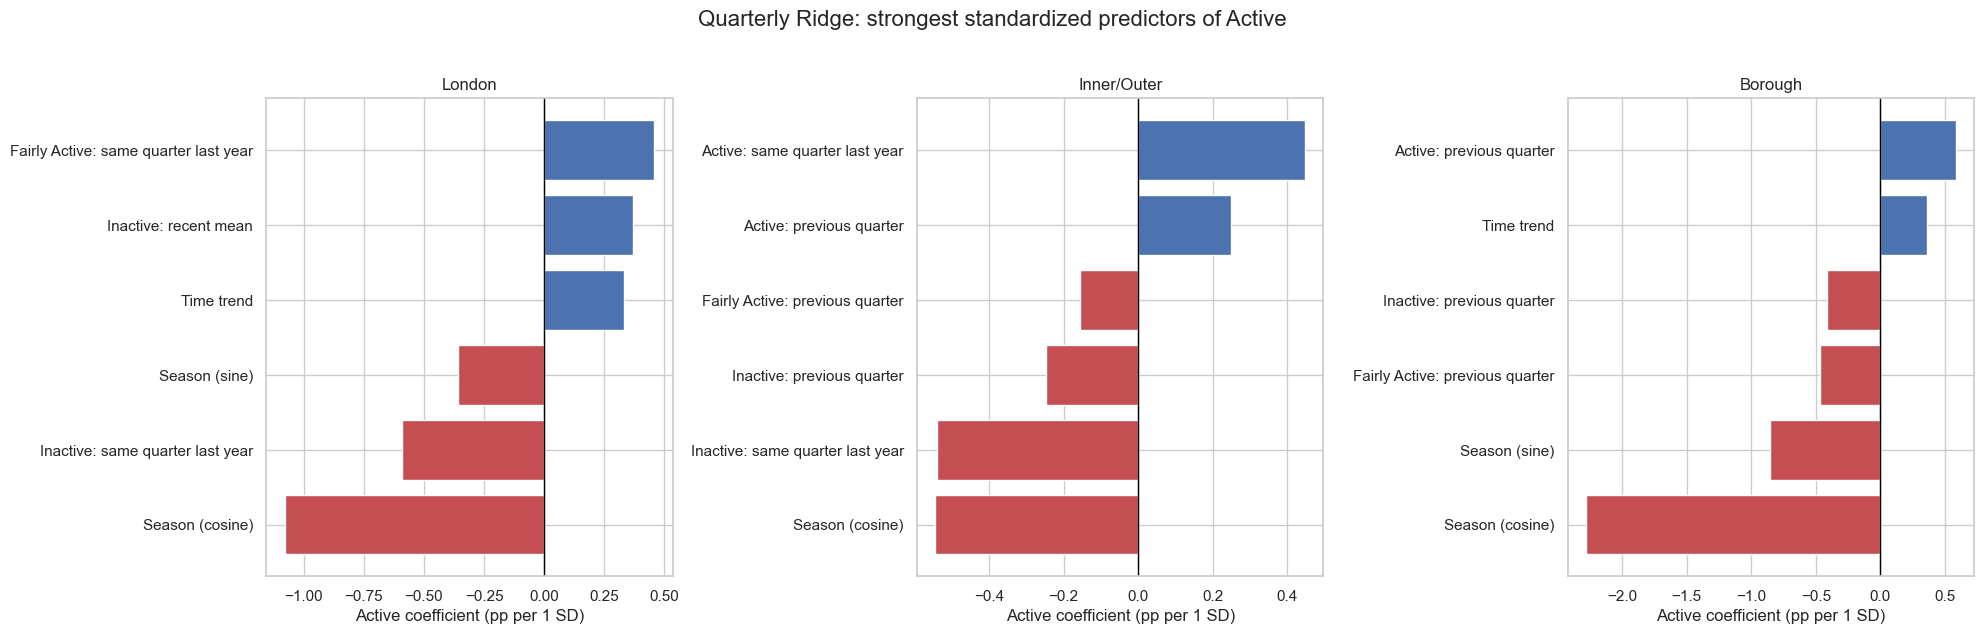

In [9]:
# Explain the three supplementary quarterly Ridge forecasts using Year 7 only.
quarterly_config = FREQUENCY_CONFIG['Quarterly']
quarterly_feature_groups = {
    'Previous quarter': [f'{target}_lag1' for target in TARGETS],
    'Same quarter last year': [f'{target}_seasonal_lag' for target in TARGETS],
    'Recent two-quarter mean': [f'{target}_recent_mean' for target in TARGETS],
    'Trend and seasonality': ['trend_years', 'season_sin', 'season_cos'],
}

# Refit the full and reduced specifications on the identical Years 1-6 sample.
ablation_rows = []
for level in LEVELS:
    choice = task_choices[(level, 'Quarterly')]
    training = panels[(level, 'Quarterly')].loc[lambda frame: frame['year'].le(6)].copy()
    validation = panels[(level, 'Quarterly')].loc[lambda frame: frame['year'].eq(7)].copy()
    full_forecast = recursive_forecast(
        training, quarterly_config, choice['model'], choice['external_features'], horizon=4,
        model_parameters=choice['parameters'],
    )
    full_matched, _ = score_forecast(full_forecast, validation, quarterly_config)
    full_error = np.average(full_matched['row_tv'], weights=full_matched['effective_n'])

    for group_name, excluded in quarterly_feature_groups.items():
        reduced_forecast = recursive_forecast(
            training, quarterly_config, choice['model'], choice['external_features'],
            horizon=4, excluded_features=excluded,
            model_parameters=choice['parameters'],
        )
        reduced_matched, _ = score_forecast(reduced_forecast, validation, quarterly_config)
        reduced_error = np.average(
            reduced_matched['row_tv'], weights=reduced_matched['effective_n']
        )
        ablation_rows.append({
            'Geography': level, 'Feature group': group_name,
            'Error increase (pp)': (reduced_error - full_error) * 100,
        })

ablation_results = pd.DataFrame(ablation_rows)
ablation_matrix = ablation_results.pivot(
    index='Feature group', columns='Geography', values='Error increase (pp)'
).reindex(index=quarterly_feature_groups, columns=LEVELS)

# A compact diverging heatmap makes helpful and unhelpful groups immediately visible.
limit = max(.05, np.abs(ablation_matrix.to_numpy()).max())
fig, axis = plt.subplots(figsize=(10.5, 5.2))
sns.heatmap(
    ablation_matrix, cmap='RdYlGn_r', center=0, vmin=-limit, vmax=limit,
    annot=True, fmt='+.2f', linewidths=.6,
    cbar_kws={'label': 'Increase in Year 7 weighted TV error (pp)'}, ax=axis,
)
axis.set(title='Quarterly feature-group ablation', xlabel='', ylabel='')
fig.tight_layout()
plt.show()

# Fit the same Ridge specifications and extract standardized numeric coefficients.
coefficient_rows = []
for level in LEVELS:
    training = panels[(level, 'Quarterly')].loc[lambda frame: frame['year'].le(6)].copy()
    supervised, numeric_features = make_supervised(training, quarterly_config, [])
    weights = np.clip(
        supervised['effective_n'], supervised['effective_n'].quantile(.05),
        supervised['effective_n'].quantile(.95),
    )
    weights = weights / weights.mean()
    ridge_parameters = task_choices[(level, 'Quarterly')]['family_parameters'][
        'Ridge Regression'
    ]
    ridge_pipeline = build_model(
        'Ridge Regression', numeric_features, len(supervised), ridge_parameters
    )
    ridge_pipeline.fit(
        supervised[numeric_features + ['geography_code']], supervised[TARGETS],
        model__sample_weight=weights,
    )
    active_coefficients = ridge_pipeline.named_steps['model'].coef_[TARGETS.index('active_rate')]
    for feature, coefficient in zip(numeric_features, active_coefficients[:len(numeric_features)]):
        coefficient_rows.append({
            'Geography': level, 'Feature': feature,
            'Coefficient (pp)': coefficient * 100,
        })

coefficient_results = pd.DataFrame(coefficient_rows)
feature_labels = {
    **{f'{target}_lag1': f'{TARGET_LABELS[target]}: previous quarter' for target in TARGETS},
    **{f'{target}_seasonal_lag': f'{TARGET_LABELS[target]}: same quarter last year' for target in TARGETS},
    **{f'{target}_recent_mean': f'{TARGET_LABELS[target]}: recent mean' for target in TARGETS},
    'trend_years': 'Time trend', 'season_sin': 'Season (sine)', 'season_cos': 'Season (cosine)',
}
coefficient_results['Label'] = coefficient_results['Feature'].map(feature_labels)
coefficient_results['Absolute coefficient'] = coefficient_results['Coefficient (pp)'].abs()
top_coefficients = coefficient_results.sort_values(
    ['Geography', 'Absolute coefficient'], ascending=[True, False]
).groupby('Geography', as_index=False).head(6)

# Show direction and magnitude for the six strongest Active predictors in each task.
fig, axes = plt.subplots(1, 3, figsize=(20, 6.2))
for axis, level in zip(axes, LEVELS):
    local = top_coefficients.loc[
        top_coefficients['Geography'].eq(level)
    ].sort_values('Coefficient (pp)')
    colors = np.where(local['Coefficient (pp)'].ge(0), '#4C72B0', '#C44E52')
    axis.barh(local['Label'], local['Coefficient (pp)'], color=colors)
    axis.axvline(0, color='black', linewidth=1)
    axis.set(title=level, xlabel='Active coefficient (pp per 1 SD)', ylabel='')
fig.suptitle('Quarterly Ridge: strongest standardized predictors of Active', fontsize=16, y=1.02)
fig.tight_layout()
plt.show()


### What the diagnostics show

Positive ablation values indicate that the removed group helped the Year 7 forecast; negative values indicate that the reduced specification did better. These results are interpreted together with the rolling-CV model comparison because a single-year ablation can still be sensitive to that year's conditions.

The coefficient chart describes predictive associations after standardisation. Correlated lagged predictors may share information, so coefficient magnitude alone is not treated as evidence that a feature improves forecasting accuracy.


## 8. How much do the four models disagree about the future?

Historical error alone does not reveal whether models produce similar long-term paths. For each task and forecast year, the heatmap measures the gap between the highest and lowest Active forecast among Naive, Ridge, Random Forest and Gradient Boosting. Borough values are summarised by their median spread so one extreme area does not dominate the comparison.

A widening band means the future result depends increasingly on model assumptions. It is a warning about structural uncertainty even when the selected model has the lowest historical error.


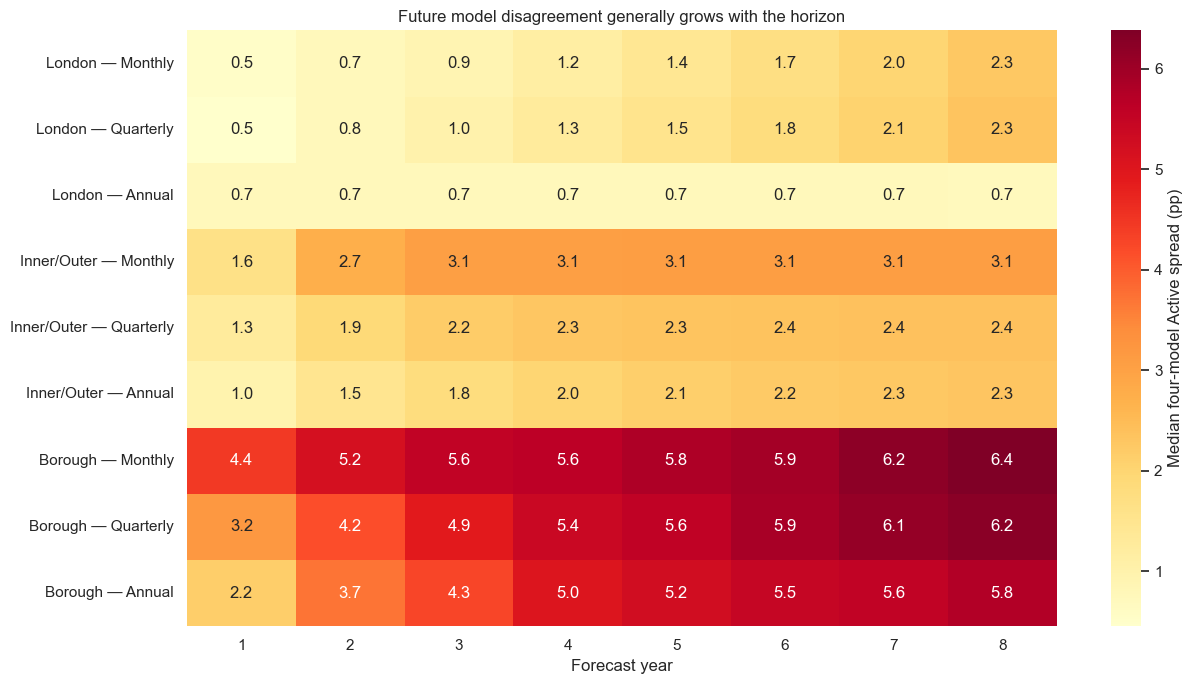

,Geography,Frequency,Median spread (pp),90th percentile spread (pp)
7,London,Monthly,2.3,2.3
15,London,Quarterly,2.3,2.3
23,London,Annual,0.7,0.7
31,Inner/Outer,Monthly,3.1,3.3
39,Inner/Outer,Quarterly,2.4,3.0
47,Inner/Outer,Annual,2.3,3.5
55,Borough,Monthly,6.4,10.3
63,Borough,Quarterly,6.2,9.2
71,Borough,Annual,5.8,9.5


In [10]:
# Measure future Active disagreement across all four fitted model families.
model_spread_rows = []
for level in LEVELS:
    for frequency in FREQUENCIES:
        local = future_forecasts.loc[
            future_forecasts['geographic_level'].eq(level)
            & future_forecasts['frequency'].eq(frequency)
        ].copy()
        periods = FREQUENCY_CONFIG[frequency]['periods_per_year']
        local['forecast_year'] = ((local['future_step'] - 1) // periods + 1).astype(int)
        annual_model_values = local.groupby([
            'geography_code', 'forecast_year', 'model'
        ], as_index=False)['predicted_active_rate'].mean()
        # Calculate and store by area for the following analysis step.
        by_area = annual_model_values.groupby([
            'geography_code', 'forecast_year'
        ])['predicted_active_rate'].agg(lambda values: values.max() - values.min()).reset_index()
        yearly = by_area.groupby('forecast_year')['predicted_active_rate'].agg(
            median_spread='median', p90_spread=lambda values: values.quantile(.90)
        ).reset_index()
        yearly['Geography'], yearly['Frequency'] = level, frequency
        # Fit the specified model to the prepared analysis sample.
        model_spread_rows.append(yearly)

# Fit the model using the specification defined for this comparison.
model_disagreement = pd.concat(model_spread_rows, ignore_index=True)
model_disagreement['Task'] = (
    model_disagreement['Geography'] + ' — ' + model_disagreement['Frequency']
)
spread_matrix = model_disagreement.pivot(
    index='Task', columns='forecast_year', values='median_spread'
).reindex([f'{level} — {frequency}' for level in LEVELS for frequency in FREQUENCIES]) * 100

# Build the figure that presents the comparison clearly.
fig, axis = plt.subplots(figsize=(13, 7))
sns.heatmap(spread_matrix, cmap='YlOrRd', annot=True, fmt='.1f',
            cbar_kws={'label': 'Median four-model Active spread (pp)'}, ax=axis)
axis.set(title='Future model disagreement generally grows with the horizon',
         xlabel='Forecast year', ylabel='')
fig.tight_layout()
plt.show()

# Calculate and store final year disagreement for the following analysis step.
final_year_disagreement = model_disagreement.loc[
    model_disagreement['forecast_year'].eq(8),
    ['Geography', 'Frequency', 'median_spread', 'p90_spread'],
].copy()
final_year_disagreement[['median_spread', 'p90_spread']] *= 100
display(final_year_disagreement.rename(columns={
    'median_spread': 'Median spread (pp)', 'p90_spread': '90th percentile spread (pp)'
}).round(1))


## 9. Annual rolling-origin stability

Fold-specific errors show whether each selected annual specification performs consistently across validation Years 4–7. This diagnostic uses the same expanding-window forecasts as formal model selection and introduces no additional forecast origin. Mean error determines selection, while dispersion across folds describes temporal stability.


,geographic_level,model,validation_year,Weighted TV (pp)
0,Borough,Ridge Regression,4,4.259
1,Borough,Ridge Regression,5,4.614
2,Borough,Ridge Regression,6,3.094
3,Borough,Ridge Regression,7,3.324
4,Inner/Outer,Naive baseline,4,1.114
5,Inner/Outer,Naive baseline,5,2.454
6,Inner/Outer,Naive baseline,6,0.457
7,Inner/Outer,Naive baseline,7,1.823
8,London,Naive baseline,4,0.099
9,London,Naive baseline,5,2.245


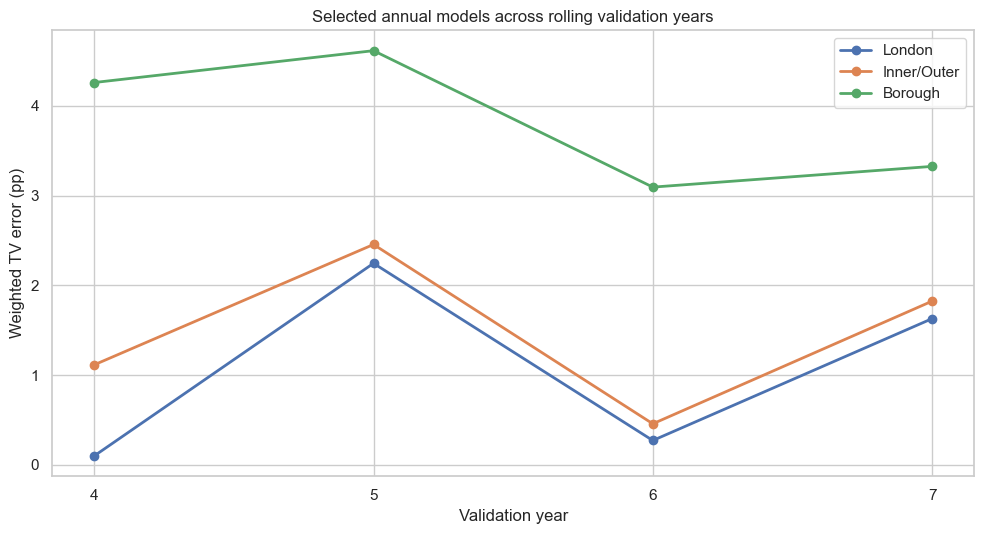

In [11]:
# Summarise the four validation years for the selected annual specifications.
annual_fold_stability = validation_predictions.loc[
    validation_predictions['frequency'].eq('Annual')
].groupby([
    'geographic_level', 'model', 'cv_fold', 'validation_year'
]).apply(
    lambda frame: np.average(frame['row_tv'], weights=frame['effective_n']),
    include_groups=False,
).rename('weighted_tv').reset_index()

display(annual_fold_stability.assign(
    **{'Weighted TV (pp)': annual_fold_stability['weighted_tv'] * 100}
)[['geographic_level', 'model', 'validation_year', 'Weighted TV (pp)']].round(3))

fig, axis = plt.subplots(figsize=(10, 5.5))
for level, color in zip(LEVELS, ['#4C72B0', '#DD8452', '#55A868']):
    line = annual_fold_stability.loc[
        annual_fold_stability['geographic_level'].eq(level)
    ].sort_values('validation_year')
    axis.plot(
        line['validation_year'], line['weighted_tv'] * 100,
        marker='o', linewidth=2, color=color, label=level,
    )
axis.set(
    title='Selected annual models across rolling validation years',
    xlabel='Validation year', ylabel='Weighted TV error (pp)',
    xticks=[4, 5, 6, 7],
)
axis.legend()
fig.tight_layout()
plt.show()


## 10. Reporting frequencies and supplementary quarterly change summary

The **annual forecast is the primary result**, matching the substantive reporting horizon and reducing short-term survey noise. Its limited eight-year history is addressed through four expanding-window validation folds, fold-level stability reporting and a separate Year 8 test.

Quarterly forecasts provide supplementary evidence about within-year dynamics and the consistency of longer-term direction. They do not replace the annual model-selection results. Monthly estimates are reported in the appendix because their greater sampling variability and 96-step recursive horizon make them less suitable for the main long-term interpretation.

The change summary compares the average of the last four observed quarters with the average of the four quarters in forecast Year 8. This keeps the target definition consistent while removing quarter-specific seasonality. London, Inner and Outer London are reported directly; the borough distribution and largest projected changes are shown separately.


,Geography,Area,Quarterly model,Inactive change (pp),Fairly Active change (pp),Active change (pp)
32,Inner/Outer,Inner London,Random Forest,-0.3,0.8,-0.5
33,Inner/Outer,Outer London,Random Forest,-0.9,0.6,0.3
34,London,London excluding City of London,Ridge Regression,1.2,-3.2,2.0


,Boroughs,Median Active change (pp),Minimum Active change (pp),Maximum Active change (pp)
0,32,-1.3,-7.7,11.2


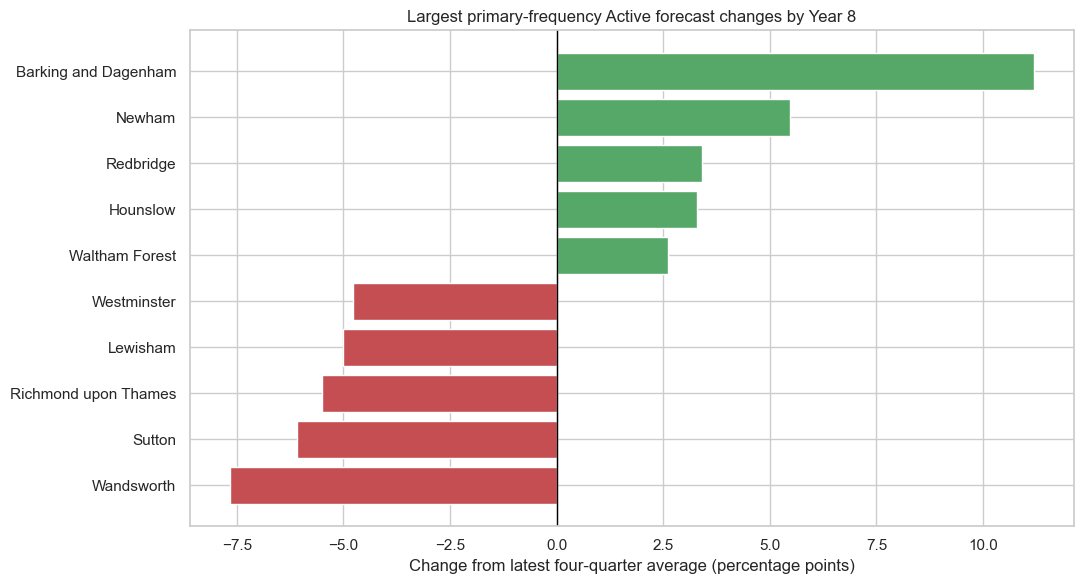

In [12]:
# Summarise forecast change using the supplementary quarterly frequency.
supplementary_quarterly = selected_forecasts.loc[
    selected_forecasts['frequency'].eq('Quarterly')
].copy()
supplementary_quarterly['forecast_year'] = (
    (supplementary_quarterly['future_step'] - 1) // 4 + 1
).astype(int)
supplementary_final = supplementary_quarterly.loc[
    supplementary_quarterly['forecast_year'].eq(8)
].groupby([
    'geographic_level', 'geography_code', 'geography_name', 'model'
], as_index=False)[[f'predicted_{target}' for target in TARGETS]].mean()

# Define the time split or forecast horizon used for evaluation.
latest_parts = []
for level in LEVELS:
    panel = panels[(level, 'Quarterly')]
    last_quarter = panel['quarter_index'].max()
    latest = panel.loc[panel['quarter_index'].gt(last_quarter - 4)].groupby([
        'geography_code', 'geography_name'
    ], as_index=False)[TARGETS].mean()
    latest_parts.append(latest.assign(geographic_level=level))
# Define the time split or forecast horizon used for evaluation.
latest_quarterly_year = pd.concat(latest_parts, ignore_index=True)

change_summary = supplementary_final.merge(
    latest_quarterly_year[['geographic_level', 'geography_code', *TARGETS]],
    on=['geographic_level', 'geography_code'], validate='one_to_one',
)
for target in TARGETS:
    change_summary[f'{target}_change_pp'] = (
        change_summary[f'predicted_{target}'] - change_summary[target]
    ) * 100

# Calculate and store aggregate change for the following analysis step.
aggregate_change = change_summary.loc[
    change_summary['geographic_level'].isin(['London', 'Inner/Outer'])
][[
    'geographic_level', 'geography_name', 'model',
    'inactive_rate_change_pp', 'fairly_active_rate_change_pp', 'active_rate_change_pp',
]].rename(columns={
    'geographic_level': 'Geography', 'geography_name': 'Area', 'model': 'Quarterly model',
    'inactive_rate_change_pp': 'Inactive change (pp)',
    'fairly_active_rate_change_pp': 'Fairly Active change (pp)',
    'active_rate_change_pp': 'Active change (pp)',
})
# Display the finished visual or summary for interpretation.
display(aggregate_change.round(1))

borough_change = change_summary.loc[
    change_summary['geographic_level'].eq('Borough')
].sort_values('active_rate_change_pp')
borough_distribution = pd.DataFrame([{
    'Boroughs': borough_change['geography_code'].count(),
    'Median Active change (pp)': borough_change['active_rate_change_pp'].median(),
    'Minimum Active change (pp)': borough_change['active_rate_change_pp'].min(),
    'Maximum Active change (pp)': borough_change['active_rate_change_pp'].max(),
}])
# Display the finished visual or summary for interpretation.
display(borough_distribution.round(1))

extremes = pd.concat([borough_change.head(5), borough_change.tail(5)]).sort_values(
    'active_rate_change_pp'
)
fig, axis = plt.subplots(figsize=(11, 6))
colors = np.where(extremes['active_rate_change_pp'].ge(0), '#55A868', '#C44E52')
# Calculate and store axis.barh(extremes['geography name'], extremes['active rate... for the following analysis step.
axis.barh(extremes['geography_name'], extremes['active_rate_change_pp'], color=colors)
axis.axvline(0, color='black', linewidth=1)
axis.set(title='Largest primary-frequency Active forecast changes by Year 8',
         xlabel='Change from latest four-quarter average (percentage points)', ylabel='')
fig.tight_layout()
plt.show()


# Final findings

## Four-origin rolling validation

Years 1–3 predict Year 4, Years 1–4 predict Year 5, Years 1–5 predict Year 6, and Years 1–6 predict Year 7. Mean weighted TV across the four origins selects each model's parameters and then the model family. Year 8 is touched once after the final specification is refitted on Years 1–7. External variables remain a separate experiment and do not alter the official test or future forecasts.

## Final external-variable definitions

The final experiment uses one readily interpretable variable from each dimension:

- age: population aged 65+;
- population: annual adult-population growth;
- income: median weekly earnings.

All three enter with a one-year lag and are tested separately. There are no interaction or combination models. The heatmap reports negative as well as positive results: interpretability alone is not treated as evidence of predictive value.

The external-variable table reports all positive and negative Year 7 results transparently. These variables support interpretation but do not enter the official specification.

## How to interpret the experiment

The Year 7 comparison asks whether each variable improves the already-selected base family. A variable that helps one geographic level or frequency is not assumed to help the others. Annual improvements remain weak temporal evidence because the validation block contains only one annual period.

None of the three variables is promoted. Year 8 test errors, future model disagreement, uncertainty bands and eight-year forecasts all continue to use activity history, seasonality and trend only.

## Quarterly forecast explanation

The Year 7 feature-group ablation is a supplementary diagnostic of the selected quarterly specifications. Standardized Ridge coefficients are reported as predictive associations for the Active equation, not as causal effects, and are interpreted alongside the rolling-CV evidence.

## Official forecasting result

Annual forecasts provide the main results. Quarterly forecasts provide supplementary higher-frequency evidence, while monthly results are reported in the appendix. Model selection is based exclusively on the four expanding rolling origins, followed by the reserved Year 8 test.


# Report figures

The report figures summarise annual results and supplementary quarterly evidence at London, Inner/Outer and Borough levels. Quarterly paths are averaged within forecast year for presentation. The model-comparison figure excludes monthly results and pairs annual/quarterly rolling-CV skill with fold-specific stability of the selected annual models.

Asterisks in the model heatmap identify the model selected by the predefined 2% simple-model rule. Positive skill means lower mean rolling-CV error than the Naive baseline.


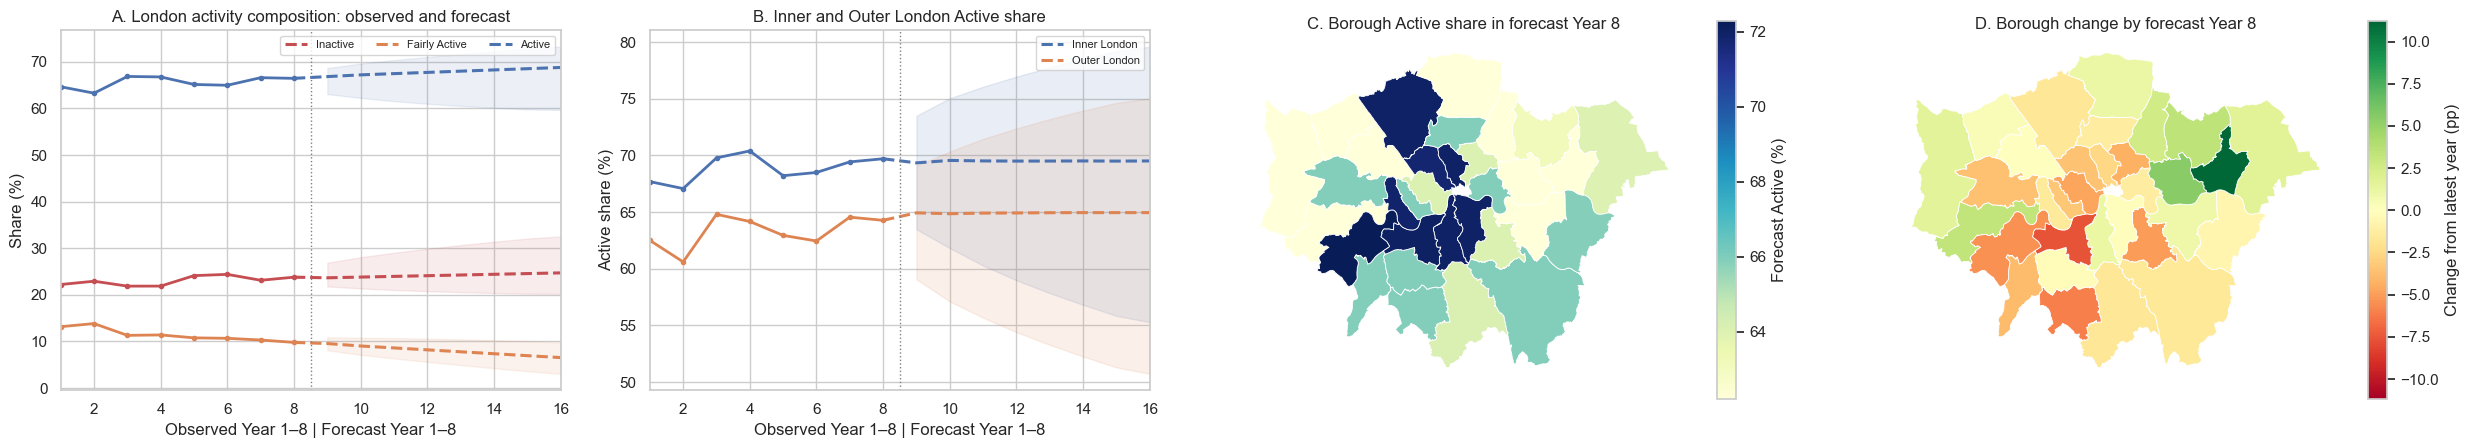

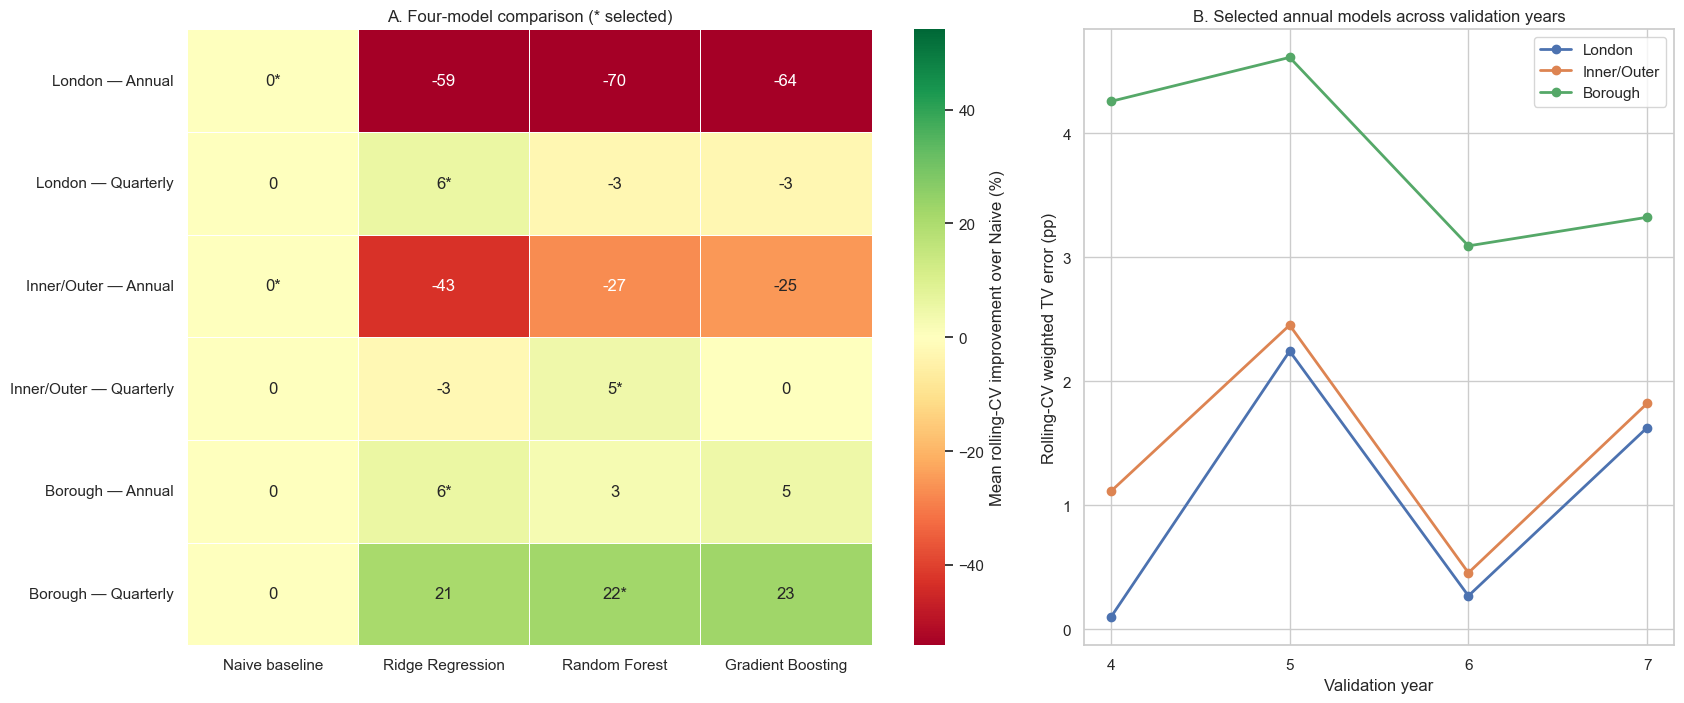

In [13]:
# Annualise the supplementary quarterly display for report presentation.
report_quarterly = selected_forecasts.loc[
    selected_forecasts['frequency'].eq('Quarterly')
].copy()
report_quarterly['forecast_year'] = ((report_quarterly['future_step'] - 1) // 4 + 1).astype(int)
forecast_columns = [
    column for target in TARGETS
    for column in (f'predicted_{target}', f'lower_{target}', f'upper_{target}')
]
report_annualised = report_quarterly.groupby([
    'geographic_level', 'geography_code', 'geography_name', 'forecast_year'
], as_index=False)[forecast_columns].mean()

# Figure 1 combines future paths and final-year spatial differences.
target_colors = {'inactive_rate': '#C44E52', 'fairly_active_rate': '#DD8452', 'active_rate': '#4C72B0'}
london_history = panels[('London', 'Annual')].sort_values('year')
london_future = report_annualised.loc[
    report_annualised['geographic_level'].eq('London')
].sort_values('forecast_year')
area_history = panels[('Inner/Outer', 'Annual')].sort_values(['geography_name', 'year'])
area_future = report_annualised.loc[
    report_annualised['geographic_level'].eq('Inner/Outer')
].sort_values(['geography_name', 'forecast_year'])
map_limit = max(abs(forecast_map['change_pp'].min()), abs(forecast_map['change_pp'].max()))

def plot_london_forecast(axis):
    for target in TARGETS:
        color = target_colors[target]
        axis.plot(
            london_history['year'], london_history[target] * 100,
            color=color, linewidth=2, marker='o', markersize=3,
        )
        future_x = london_future['forecast_year'] + 8
        joined_x = np.r_[8, future_x]
        joined_y = np.r_[london_history[target].iloc[-1] * 100,
                         london_future[f'predicted_{target}'] * 100]
        axis.plot(
            joined_x, joined_y, color=color, linewidth=2.2, linestyle='--',
            label=TARGET_LABELS[target],
        )
        axis.fill_between(
            future_x, london_future[f'lower_{target}'] * 100,
            london_future[f'upper_{target}'] * 100, color=color, alpha=.10,
        )
    axis.axvline(8.5, color='grey', linestyle=':', linewidth=1)
    axis.set(
        title='A. London activity composition: observed and forecast',
        xlabel='Observed Year 1–8 | Forecast Year 1–8', ylabel='Share (%)', xlim=(1, 16),
    )
    axis.legend(ncol=3, fontsize=8, loc='best')

def plot_area_forecast(axis):
    for area_name, color in [('Inner London', '#4C72B0'), ('Outer London', '#DD8452')]:
        observed = area_history.loc[area_history['geography_name'].eq(area_name)]
        future = area_future.loc[area_future['geography_name'].eq(area_name)]
        axis.plot(
            observed['year'], observed['active_rate'] * 100,
            color=color, linewidth=2, marker='o', markersize=3,
        )
        future_x = future['forecast_year'] + 8
        axis.plot(
            np.r_[8, future_x],
            np.r_[observed['active_rate'].iloc[-1] * 100, future['predicted_active_rate'] * 100],
            color=color, linewidth=2.2, linestyle='--', label=area_name,
        )
        axis.fill_between(
            future_x, future['lower_active_rate'] * 100,
            future['upper_active_rate'] * 100, color=color, alpha=.12,
        )
    axis.axvline(8.5, color='grey', linestyle=':', linewidth=1)
    axis.set(
        title='B. Inner and Outer London Active share',
        xlabel='Observed Year 1–8 | Forecast Year 1–8', ylabel='Active share (%)', xlim=(1, 16),
    )
    axis.legend(fontsize=8)

def plot_level_map(axis):
    forecast_map.plot(
        column='predicted_active_pct', cmap='YlGnBu', edgecolor='white', linewidth=.6,
        legend=True, legend_kwds={'label': 'Forecast Active (%)', 'shrink': .78}, ax=axis,
    )
    axis.set_title('C. Borough Active share in forecast Year 8')
    axis.set_axis_off()

def plot_change_map(axis):
    forecast_map.plot(
        column='change_pp', cmap='RdYlGn', vmin=-map_limit, vmax=map_limit,
        edgecolor='white', linewidth=.6, legend=True,
        legend_kwds={'label': 'Change from latest year (pp)', 'shrink': .78}, ax=axis,
    )
    axis.set_title('D. Borough change by forecast Year 8')
    axis.set_axis_off()

def plot_forecast_layout():
    # Maps receive wider slots to offset their fixed aspect ratio and colour bars.
    fig, panel_axes = plt.subplots(
        1, 4, figsize=(25, 5.2),
        gridspec_kw={'width_ratios': [1.2, 1.2, 1.35, 1.35]},
    )
    for draw_panel, axis in zip(
        [plot_london_forecast, plot_area_forecast, plot_level_map, plot_change_map],
        panel_axes,
    ):
        draw_panel(axis)
    # Keep the line charts landscape-shaped and visually comparable with the maps.
    for axis in panel_axes[:2]:
        axis.set_box_aspect(.72)
    fig.tight_layout(w_pad=1.8)
    plt.show()

plot_forecast_layout()

# Figure 2 summarises annual/quarterly model choice and annual fold stability.
report_models = model_summary.loc[
    model_summary['frequency'].isin(['Annual', 'Quarterly'])
].merge(
    model_summary.loc[model_summary['model'].eq('Naive baseline'), [
        'geographic_level', 'frequency', 'mean'
    ]].rename(columns={'mean': 'naive_error'}),
    on=['geographic_level', 'frequency'], validate='many_to_one',
)
report_models['Skill versus Naive (%)'] = (1 - report_models['mean'] / report_models['naive_error']) * 100
report_models['Task'] = report_models['geographic_level'] + ' — ' + report_models['frequency']
task_order = [
    f'{level} — {frequency}' for level in LEVELS
    for frequency in ['Annual', 'Quarterly']
]
skill_matrix = report_models.pivot(
    index='Task', columns='model', values='Skill versus Naive (%)'
).reindex(index=task_order, columns=MODELS)
selected_matrix = report_models.pivot(
    index='Task', columns='model', values='selected'
).reindex(index=task_order, columns=MODELS)
annotations = np.array([
    [f'{value:.0f}' + ('*' if selected_matrix.iloc[row, column] else '')
     for column, value in enumerate(skill_matrix.iloc[row])]
    for row in range(len(skill_matrix))
])
color_limit = max(10, np.nanpercentile(np.abs(skill_matrix.to_numpy()), 90))

fig, axes = plt.subplots(1, 2, figsize=(17, 7.2), gridspec_kw={'width_ratios': [1.45, 1]})
sns.heatmap(
    skill_matrix, cmap='RdYlGn', center=0, vmin=-color_limit, vmax=color_limit,
    annot=annotations, fmt='', linewidths=.4,
    cbar_kws={'label': 'Mean rolling-CV improvement over Naive (%)'}, ax=axes[0],
)
axes[0].set(title='A. Four-model comparison (* selected)', xlabel='', ylabel='')

for level, color in zip(LEVELS, ['#4C72B0', '#DD8452', '#55A868']):
    line = annual_fold_stability.loc[
        annual_fold_stability['geographic_level'].eq(level)
    ].sort_values('validation_year')
    axes[1].plot(
        line['validation_year'], line['weighted_tv'] * 100,
        marker='o', linewidth=2, color=color, label=level,
    )
axes[1].set(
    title='B. Selected annual models across validation years',
    xlabel='Validation year', ylabel='Rolling-CV weighted TV error (pp)',
    xticks=[4, 5, 6, 7],
)
axes[1].legend()
fig.tight_layout()
plt.show()
